# 2.2. t-SNE — ręcznie, matematycznie i jako mini-projekt

Ten notebook jest pomostem między PCA/UMAP a samodzielnym eksperymentem badawczym.

Pokazuje t-SNE w logice:

$$
\text{odległości}
\rightarrow
P
\rightarrow
Q
\rightarrow
\mathrm{KL}(P\|Q)
\rightarrow
\text{przesuwanie punktów}.
$$

Najważniejsza różnica względem PCA:

- **PCA** szuka nowych osi liniowych i maksymalizuje wariancję,
- **t-SNE** nie szuka osi interpretowalnych, tylko tak przesuwa punkty, aby podobieństwa sąsiedzkie w małym wymiarze przypominały podobieństwa w dużym wymiarze.

Najważniejsza różnica względem UMAP:

- **t-SNE** buduje probabilistyczną macierz podobieństw $P$,
- **UMAP** buduje fuzzy graf sąsiedztw $P$.


## W tym notebooku użyjemy

✓ Macierzy odległości D

✓ Macierzy podobieństw P

✗ Macierzy kowariancji
✗ Centroidów

## Do jakiej rodziny należy metoda?

PCA:
→ metody projekcyjne

t-SNE:
→ metody podobieństw

UMAP:
→ metody grafowe

KNN:
→ metody sąsiedztwa

DBSCAN:
→ metody gęstościowe

KMeans:
→ metody centroidowe

LDA:
→ metody dyskryminacyjne

SVM:
→ metody maksymalnego marginesu

## Mapa pojęć: co student ma wynieść z tego notebooka?

Po tym notebooku student powinien rozumieć cztery rzeczy:

1. t-SNE zaczyna od **odległości między punktami**, ale szybko zamienia je na **prawdopodobieństwa sąsiedztwa**.
2. Macierz $P$ opisuje podobieństwa w przestrzeni wejściowej, a macierz $Q$ — podobieństwa po rzutowaniu do 1D/2D.
3. Funkcja celu $\mathrm{KL}(P\|Q)$ szczególnie mocno karze sytuację, gdy bliskie punkty z oryginalnej przestrzeni zostają rozrzucone daleko.
4. W mini-projekcie badawczym modyfikujemy nie samą optymalizację t-SNE, lecz **macierz $P$**, czyli definicję tego, co metoda ma zachować.

To jest dobry dydaktyczny kontrast z PCA: w PCA wszystko dzieje się przez macierz kowariancji i osie własne, a w t-SNE przez macierze podobieństw par punktów.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

np.set_printoptions(precision=3, suppress=True)

labels = list("ABCDEF")
colors = {
    "A": "tab:blue", "B": "tab:red", "C": "tab:pink",
    "D": "gold", "E": "khaki", "F": "lemonchiffon"
}

# Ręcznie ustawiona macierz odległości inspirowana przykładem A,B,C oraz osobną grupą D,E,F.
# Ważne: A,B,C są jedną lokalną grupą, D,E,F drugą lokalną grupą.
D = np.array([
    [0.0, 0.5, 2.4, 10.0,  9.5,  9.8],
    [0.5, 0.0, 2.0,  9.8,  9.0,  9.2],
    [2.4, 2.0, 0.0,  8.0,  8.2,  8.0],
    [10.0,9.8, 8.0,  0.0,  0.5,  0.3],
    [9.5, 9.0, 8.2,  0.5,  0.0,  0.4],
    [9.8, 9.2, 8.0,  0.3,  0.4,  0.0],
])

coords = {
    "A": (0.0, 1.3),
    "B": (0.0, 0.8),
    "C": (2.2, 0.25),
    "D": (7.2, 0.85),
    "E": (7.8, 0.85),
    "F": (7.5, 0.45),
}
X_plot = np.array([coords[l] for l in labels])

def df_matrix(M, fmt=True):
    df = pd.DataFrame(M, index=labels, columns=labels)
    return df.round(3) if fmt else df

def plot_points(ax=None, title="Punkty wejściowe", annotate_distances=True):
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 3.6))
    for i, lab in enumerate(labels):
        ax.scatter(X_plot[i,0], X_plot[i,1], s=260, color=colors[lab], edgecolor='black', zorder=3)
        ax.text(X_plot[i,0], X_plot[i,1]+0.18, lab, ha='center', va='bottom', fontsize=14, fontweight='bold')
    if annotate_distances:
        pairs = [("A","B",0.5),("B","C",2.0),("A","C",2.4),("D","E",0.5),("D","F",0.3),("E","F",0.4)]
        for a,b,val in pairs:
            ia, ib = labels.index(a), labels.index(b)
            xa, ya = X_plot[ia]
            xb, yb = X_plot[ib]
            ax.plot([xa,xb],[ya,yb], color='0.75', linestyle='--', zorder=1)
            ax.text((xa+xb)/2, (ya+yb)/2+0.08, f"{val}", ha='center', fontsize=10, color='0.35')
    ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-0.8, 8.6)
    ax.set_ylim(-0.2, 1.8)
    ax.axis('off')
    return ax

def plot_heatmap(M, title, ax=None, vmin=0, vmax=1, cmap='Reds', annotate=True):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,4))
    im = ax.imshow(M, vmin=vmin, vmax=vmax, cmap=cmap)
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels); ax.set_yticklabels(labels)
    ax.set_title(title)
    if annotate:
        for i in range(M.shape[0]):
            for j in range(M.shape[1]):
                val = M[i,j]
                txt = "" if np.isnan(val) else f"{val:.2f}"
                ax.text(j, i, txt, ha='center', va='center', fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return ax

def directed_knn_indices(D, n_neighbors=2):
    neigh = []
    for i in range(D.shape[0]):
        order = np.argsort(D[i])
        order = [j for j in order if j != i]
        neigh.append(order[:n_neighbors])
    return neigh

def solve_sigma_for_two_neighbors(distances, target=np.log2(3)):
    # Zakładamy local_connectivity=1: najbliższy sąsiad po przesunięciu rho ma wagę 1.
    # Dla drugiego sąsiada dobieramy sigma tak, aby 1 + exp(-(d2-rho)/sigma) = target.
    rho = min(distances)
    other = max(distances)
    desired_other = target - 1.0
    if other == rho:
        return 1.0, rho
    sigma = (other - rho) / (-np.log(desired_other))
    return sigma, rho

def umap_directed_scores(D, n_neighbors=2, target=np.log2(3)):
    n = D.shape[0]
    neigh = directed_knn_indices(D, n_neighbors=n_neighbors)
    Pdir = np.zeros((n,n))
    sigmas = np.zeros(n)
    rhos = np.zeros(n)
    for i in range(n):
        distances = [D[i,j] for j in neigh[i]]
        sigma, rho = solve_sigma_for_two_neighbors(distances, target=target)
        sigmas[i] = sigma
        rhos[i] = rho
        for j in neigh[i]:
            Pdir[i,j] = np.exp(-max(0.0, D[i,j]-rho)/sigma)
    return Pdir, np.array(sigmas), np.array(rhos), neigh

def fuzzy_union(Pdir):
    return Pdir + Pdir.T - Pdir * Pdir.T

def low_dim_q_umap(y, a=1.577, b=0.8951):
    y = np.asarray(y).reshape(-1, 1)
    dist = np.abs(y - y.T)
    Q = 1.0 / (1.0 + a * (dist ** (2*b)))
    np.fill_diagonal(Q, 1.0)
    return Q

def cross_entropy_binary(P, Q, eps=1e-7):
    mask = ~np.eye(P.shape[0], dtype=bool)
    Pm = P[mask]
    Qm = np.clip(Q[mask], eps, 1-eps)
    return -np.sum(Pm*np.log(Qm) + (1-Pm)*np.log(1-Qm)) / 2


## 1. Dane i macierz odległości

Tutaj celowo używamy małego, sztucznego przykładu z sześcioma punktami.

Ważna uwaga dydaktyczna: w tej pierwszej części najważniejsza jest **macierz odległości $D$**, a nie sama geometria narysowanych punktów. Rysunek pomaga widzieć dwie lokalne grupy, ale t-SNE w obliczeniach korzysta z wartości w macierzy $D$.


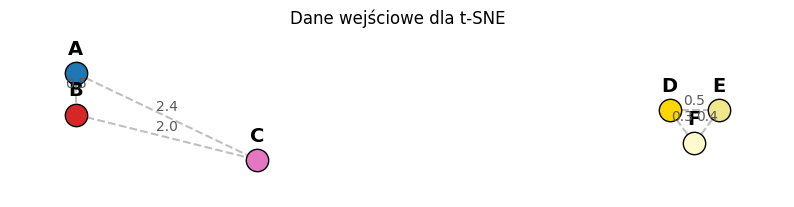

,A,B,C,D,E,F
A,0.0,0.5,2.4,10.0,9.5,9.8
B,0.5,0.0,2.0,9.8,9.0,9.2
C,2.4,2.0,0.0,8.0,8.2,8.0
D,10.0,9.8,8.0,0.0,0.5,0.3
E,9.5,9.0,8.2,0.5,0.0,0.4
F,9.8,9.2,8.0,0.3,0.4,0.0


In [2]:
fig, ax = plt.subplots(figsize=(10,3.8))
plot_points(ax, title="Dane wejściowe dla t-SNE")
plt.show()
display(df_matrix(D))


## 2. Wysokowymiarowe podobieństwa t-SNE

Dla każdego punktu $i$ t-SNE liczy warunkowe prawdopodobieństwa:

$$
 p(j\mid i)=
 \frac{\exp\left(-\frac{d(x_i,x_j)^2}{2\sigma_i^2}\right)}
 {\sum_{k\neq i}\exp\left(-\frac{d(x_i,x_k)^2}{2\sigma_i^2}\right)}.
$$

Parametr $\sigma_i$ jest dobierany tak, aby rozkład miał zadaną perplexity:

$$
H(P_i)=-\sum_j p(j\mid i)\log_2 p(j\mid i),
$$

$$
\operatorname{Perp}(P_i)=2^{H(P_i)}.
$$

W tym mini-przykładzie ustawiamy ręcznie $\sigma_i=1.0$, żeby najpierw zobaczyć mechanikę.


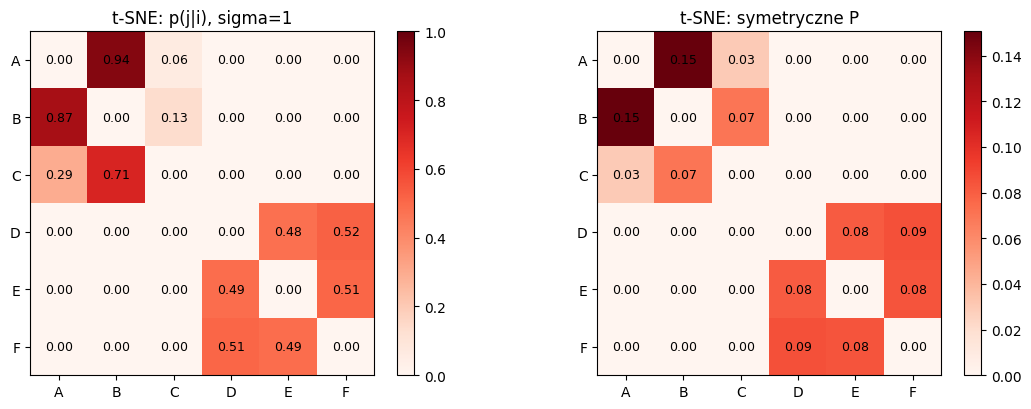

,A,B,C,D,E,F
A,0.000,0.940,0.060,0.000,0.000,0.000
B,0.867,0.000,0.133,0.000,0.000,0.000
C,0.293,0.707,0.000,0.000,0.000,0.000
D,0.000,0.000,0.000,0.000,0.480,0.520
E,0.000,0.000,0.000,0.489,0.000,0.511
F,0.000,0.000,0.000,0.509,0.491,0.000


In [3]:
def tsne_conditional_matrix(D, sigmas):
    n = D.shape[0]
    Pcond = np.zeros((n,n))
    for i in range(n):
        s = np.exp(-(D[i]**2)/(2*sigmas[i]**2))
        s[i] = 0
        Pcond[i] = s / s.sum()
    return Pcond

def tsne_symmetric_P(Pcond):
    n = Pcond.shape[0]
    P = (Pcond + Pcond.T) / (2*n)
    np.fill_diagonal(P, 0)
    return P

sigmas = np.ones(len(labels))
Pcond = tsne_conditional_matrix(D, sigmas)
P_tsne = tsne_symmetric_P(Pcond)

fig, axes = plt.subplots(1,2,figsize=(12,4.2))
plot_heatmap(Pcond, "t-SNE: p(j|i), sigma=1", ax=axes[0], cmap='Reds')
plot_heatmap(P_tsne, "t-SNE: symetryczne P", ax=axes[1], cmap='Reds', vmax=P_tsne.max())
plt.tight_layout()
plt.show()
display(df_matrix(Pcond))


### Jak czytać dwie macierze $P$?

W t-SNE pojawiają się dwa poziomy prawdopodobieństw:

- $p(j\mid i)$ — prawdopodobieństwo warunkowe: „jak bardzo punkt $j$ jest sąsiadem punktu $i$”.
  Każdy wiersz tej macierzy sumuje się do $1$.
- $P_{ij}$ — wersja symetryczna używana w funkcji celu.
  Po symetryzacji cała macierz sumuje się do $1$.

To drobny, ale ważny szczegół: t-SNE nie porównuje surowych odległości, tylko **rozkłady prawdopodobieństwa na parach punktów**.


In [4]:
print("Suma każdego wiersza Pcond:")
print(np.round(Pcond.sum(axis=1), 3))

print("\nSuma całej symetrycznej macierzy P:")
print(np.round(P_tsne.sum(), 6))

Suma każdego wiersza Pcond:
[1. 1. 1. 1. 1. 1.]

Suma całej symetrycznej macierzy P:
1.0


## 3. Perplexity: jak $\sigma_i$ zmienia lokalną liczbę sąsiadów?

Perplexity można traktować jako przybliżoną liczbę efektywnych sąsiadów punktu.

Małe $\sigma_i$ daje rozkład skupiony prawie tylko na najbliższym sąsiedzie.  
Duże $\sigma_i$ daje rozkład bardziej rozlany na dalsze punkty.

Formalnie:

$$
\mathrm{Perp}(P_i)=2^{H(P_i)},
$$

gdzie $H(P_i)$ jest entropią rozkładu warunkowego $p(j\mid i)$.

W prawdziwym t-SNE $\sigma_i$ nie musi być takie samo dla wszystkich punktów. Dla każdego punktu jest dobierane osobno tak, aby uzyskać zadaną perplexity. Dzięki temu punkty z gęstych i rzadkich obszarów mogą mieć porównywalną „lokalną liczbę sąsiadów”.


In [5]:
def entropy_base2(p):
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

def perplexity(p):
    return 2 ** entropy_base2(p)

rows = []
for s in [0.3, 0.6, 1.0, 2.0, 4.0]:
    p = tsne_conditional_matrix(D, np.ones(len(labels))*s)[labels.index('A')]
    rows.append({"sigma_A": s, "perplexity_A": perplexity(p), **{f"p({lab}|A)": p[j] for j,lab in enumerate(labels) if lab!='A'}})
display(pd.DataFrame(rows).round(4))


,sigma_A,perplexity_A,p(B|A),p(C|A),p(D|A),p(E|A),p(F|A)
0,0.3,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000
1,0.6,1.0041,0.9995,0.0005,0.0000,0.0000,0.0000
2,1.0,1.2541,0.9402,0.0598,0.0000,0.0000,0.0000
3,2.0,1.8915,0.6657,0.3343,0.0000,0.0000,0.0000
4,4.0,2.6988,0.5009,0.4217,0.0222,0.0301,0.0251


## 4. Niskowymiarowe podobieństwa t-SNE

W niskim wymiarze t-SNE używa rozkładu t-Studenta:

$$
 u_{ij}=\frac{1}{1+\lVert y_i-y_j\rVert^2}.
$$

Potem normalizuje globalnie:

$$
 q_{ij}=\frac{u_{ij}}{\sum_{a\neq b}u_{ab}}.
$$

To jest ważne: $Q$ w t-SNE jest globalnym rozkładem prawdopodobieństwa po parach.


Dlaczego rozkład t-Studenta, a nie znowu Gauss?

W niskim wymiarze jest mniej miejsca niż w wysokim. Gdyby użyć zbyt szybko zanikającego Gaussa, odległe punkty byłyby za mocno „ściskane”. Rozkład t-Studenta ma cięższe ogony, więc pozwala punktom, które nie są sąsiadami, odsunąć się dalej. To jest klasyczna odpowiedź t-SNE na tzw. **crowding problem**.


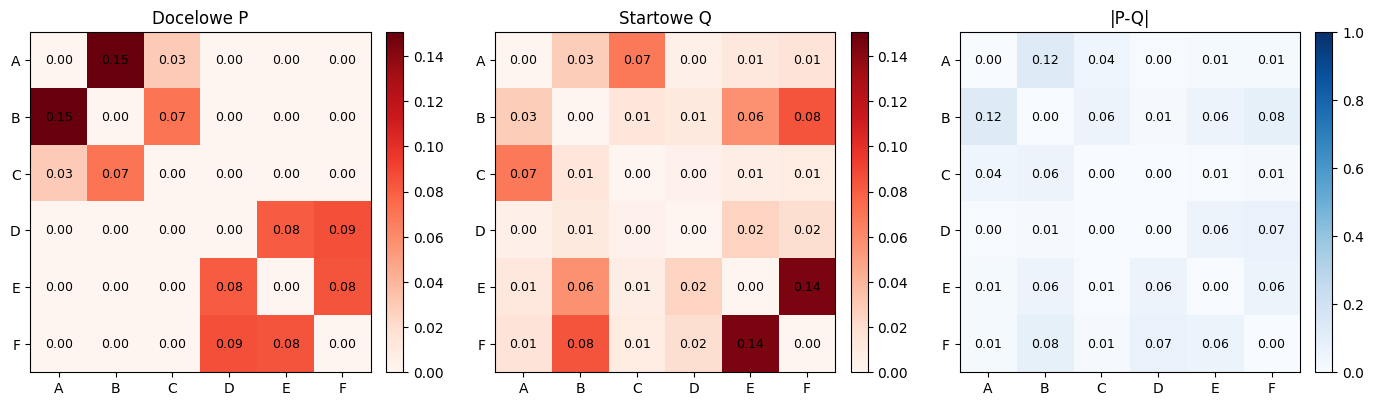

KL(P||Q0)= 1.0393097421789064


In [6]:
def tsne_Q(y):
    y = np.asarray(y).reshape(-1,1)
    dist2 = (y - y.T)**2
    U = 1/(1+dist2)
    np.fill_diagonal(U, 0)
    Q = U / U.sum()
    return Q

def kl_tsne(P, Q, eps=1e-12):
    mask = P > 0
    return np.sum(P[mask] * np.log((P[mask]+eps)/(Q[mask]+eps)))

y0 = np.array([3.8, 1.6, 5.0, -2.2, 0.2, 0.6])
Q0 = tsne_Q(y0)
fig, axes = plt.subplots(1,3,figsize=(14,4))
plot_heatmap(P_tsne, "Docelowe P", ax=axes[0], cmap='Reds', vmax=P_tsne.max())
plot_heatmap(Q0, "Startowe Q", ax=axes[1], cmap='Reds', vmax=max(P_tsne.max(), Q0.max()))
plot_heatmap(np.abs(P_tsne-Q0), "|P-Q|", ax=axes[2], cmap='Blues')
plt.tight_layout()
plt.show()
print("KL(P||Q0)=", kl_tsne(P_tsne, Q0))


## 5. Funkcja celu t-SNE

T-SNE przesuwa punkty tak, aby $Q$ było podobne do $P$.

Minimalizowana jest dywergencja KL:

$$
\mathrm{KL}(P\|Q)=\sum_{i\neq j}P_{ij}\log\frac{P_{ij}}{Q_{ij}}.
$$

Intuicja:

> Jeżeli $P_{ij}$ jest duże, a $Q_{ij}$ małe, to kara jest duża — punkty powinny się zbliżyć.


Asymetria KL ma tu znaczenie:

- jeżeli $P_{ij}$ jest duże, a $Q_{ij}$ małe, kara jest duża,
- jeżeli $P_{ij}$ jest małe, a $Q_{ij}$ duże, kara jest mniejsza.

Dlatego t-SNE bardzo dobrze chroni lokalne sąsiedztwa, ale nie należy nadinterpretować odległości między odległymi klastrami.



## 5a. Przeliczenie „na papierze”: jedna para punktów w t-SNE

Pełnego t-SNE dla 100 punktów nie warto liczyć ręcznie — to szybko robi się macierz par i optymalizacja numeryczna. Ale bardzo warto policzyć **jeden mini-fragment**, żeby było jasne, co naprawdę robi algorytm.

Policzmy parę **A–B** z pierwszego przykładu.

### Krok 1: z odległości do prawdopodobieństwa warunkowego

Dla punktu A mamy odległości:

$$
 d(A,B)=0.5, \qquad d(A,C)=2.4.
$$

Przyjmujemy tu ręcznie $\sigma_A=1$, więc wagi Gaussowskie są:

$$
 w_{AB}=\exp\left(-\frac{0.5^2}{2}\right)=0.8825,
$$

$$
 w_{AC}=\exp\left(-\frac{2.4^2}{2}\right)=0.0561.
$$

Pozostałe punkty są bardzo daleko, więc ich wagi są praktycznie zerowe.

Normalizacja daje:

$$
 p(B\mid A)=\frac{0.8825}{0.9386}=0.9402,
$$

$$
 p(C\mid A)=\frac{0.0561}{0.9386}=0.0598.
$$

Czyli A prawie całe swoje prawdopodobieństwo sąsiedztwa oddaje punktowi B.

### Krok 2: symetryzacja

W t-SNE do funkcji celu trafia macierz symetryczna:

$$
P_{ij}=\frac{p(j\mid i)+p(i\mid j)}{2n}.
$$

Dla $n=6$ i pary A–B:

$$
P_{AB}=\frac{p(B\mid A)+p(A\mid B)}{12}
      =\frac{0.9402+0.8670}{12}
      =0.1506.
$$

To oznacza: w przestrzeni wejściowej para A–B jest bardzo ważną parą sąsiedzką.

### Krok 3: porównanie z aktualną mapą 1D

Na starcie mamy ręczne pozycje:

$$
y_A=3.8, \qquad y_B=1.6.
$$

W niskim wymiarze t-SNE liczy:

$$
u_{AB}=\frac{1}{1+(y_A-y_B)^2}
        =\frac{1}{1+2.2^2}
        =0.1712.
$$

Po globalnej normalizacji:

$$
Q_{AB}=0.0287.
$$

Mamy więc:

$$
P_{AB}=0.1506, \qquad Q_{AB}=0.0287.
$$

A to znaczy: **w danych A i B są dużo bardziej podobne niż na aktualnej mapie**.

### Krok 4: wkład tej jednej komórki do KL

Dla jednej komórki macierzy:

$$
P_{AB}\log\frac{P_{AB}}{Q_{AB}}
=0.1506\log\frac{0.1506}{0.0287}
\approx 0.2497.
$$

To jest duży sygnał dla optymalizacji: A i B powinny zostać przesunięte bliżej siebie.


In [7]:

# Sprawdzenie liczb z komórki „na papierze” dla pary A-B.
# Ta komórka nie wprowadza nowego algorytmu — tylko pokazuje, skąd biorą się liczby z opisu.

A = labels.index("A")
B = labels.index("B")
C = labels.index("C")

weights_A = np.exp(-(D[A]**2) / (2 * sigmas[A]**2))
weights_A[A] = 0.0
sum_weights_A = weights_A.sum()

manual_rows = pd.DataFrame([
    {
        "wielkość": "w_AB",
        "wartość": weights_A[B],
        "interpretacja": "waga Gaussowska dla B jako sąsiada A",
    },
    {
        "wielkość": "w_AC",
        "wartość": weights_A[C],
        "interpretacja": "waga Gaussowska dla C jako sąsiada A",
    },
    {
        "wielkość": "suma wag z A",
        "wartość": sum_weights_A,
        "interpretacja": "mianownik normalizacji p(j|A)",
    },
    {
        "wielkość": "p(B|A)",
        "wartość": Pcond[A, B],
        "interpretacja": "B jest prawie całym sąsiedztwem A",
    },
    {
        "wielkość": "p(A|B)",
        "wartość": Pcond[B, A],
        "interpretacja": "A jest bardzo ważnym sąsiadem B",
    },
    {
        "wielkość": "P_AB",
        "wartość": P_tsne[A, B],
        "interpretacja": "symetryczna ważność pary A-B w t-SNE",
    },
    {
        "wielkość": "Q_AB na starcie",
        "wartość": Q0[A, B],
        "interpretacja": "ważność pary A-B na aktualnej mapie",
    },
    {
        "wielkość": "wkład KL jednej komórki",
        "wartość": P_tsne[A, B] * np.log(P_tsne[A, B] / Q0[A, B]),
        "interpretacja": "kara za to, że Q_AB jest za małe względem P_AB",
    },
])

print(manual_rows.to_string(index=False, formatters={"wartość": "{:.4f}".format}))


               wielkość wartość                                  interpretacja
                   w_AB  0.8825           waga Gaussowska dla B jako sąsiada A
                   w_AC  0.0561           waga Gaussowska dla C jako sąsiada A
           suma wag z A  0.9386                  mianownik normalizacji p(j|A)
                 p(B|A)  0.9402              B jest prawie całym sąsiedztwem A
                 p(A|B)  0.8670                A jest bardzo ważnym sąsiadem B
                   P_AB  0.1506           symetryczna ważność pary A-B w t-SNE
        Q_AB na starcie  0.0287            ważność pary A-B na aktualnej mapie
wkład KL jednej komórki  0.2497 kara za to, że Q_AB jest za małe względem P_AB


In [8]:
def tsne_loss_y(y, P):
    return kl_tsne(P, tsne_Q(y))

def numeric_grad_tsne(y, P, eps=1e-5):
    g = np.zeros_like(y)
    for i in range(len(y)):
        yp = y.copy(); ym = y.copy()
        yp[i] += eps; ym[i] -= eps
        g[i] = (tsne_loss_y(yp, P) - tsne_loss_y(ym, P)) / (2*eps)
    return g

def optimize_tsne_1d(y0, P, steps=160, lr=4.0):
    y = y0.astype(float).copy()
    hist = []
    for t in range(steps+1):
        Q = tsne_Q(y)
        loss = kl_tsne(P, Q)
        hist.append((t, y.copy(), loss, Q))
        g = numeric_grad_tsne(y, P)
        y -= lr * g
        y -= y.mean()
        y = np.clip(y, -8, 8)
    return hist

hist_tsne = optimize_tsne_1d(y0, P_tsne, steps=120, lr=3.0)
for idx in [0, 30, 80, 120]:
    t, y, loss, Q = hist_tsne[idx]
    print(f"iteracja={t:3d}, KL={loss:.4f}, y={np.round(y,2)}")


iteracja=  0, KL=1.0393, y=[ 3.8  1.6  5.  -2.2  0.2  0.6]
iteracja= 30, KL=0.0870, y=[ 2.6   2.77  3.73 -3.37 -2.87 -2.87]
iteracja= 80, KL=0.0670, y=[ 3.21  3.41  4.46 -4.08 -3.29 -3.71]
iteracja=120, KL=0.0604, y=[ 3.56  3.77  4.84 -4.46 -3.63 -4.07]



## 5b. Jeden krok gradientowy bez magii

Funkcja celu mówi, **jak zły jest aktualny układ punktów**. Gradient mówi, **w którą stronę trzeba przesunąć punkty, żeby tę złość zmniejszyć**.

W pełnym t-SNE gradient ma znaną postać analityczną, ale na tym etapie dydaktycznie wystarczy zobaczyć zasadę:

$$
y_i^{\text{nowe}}=y_i-\eta\frac{\partial KL}{\partial y_i}.
$$

Czyli:

- dodatni gradient → punkt przesuwamy w lewo,
- ujemny gradient → punkt przesuwamy w prawo,
- po kroku odejmujemy średnią, żeby cały układ nie dryfował.

Poniżej liczymy **jeden demonstracyjny krok** z tych samych pozycji startowych. To nie jest jeszcze pełna optymalizacja — tylko „papierowa” kontrola kierunku ruchu.


In [9]:

# Jeden krok gradientowy na liczbach.

lr_hand = 3.0
loss_before = tsne_loss_y(y0, P_tsne)
g0 = numeric_grad_tsne(y0, P_tsne)
raw_update = y0 - lr_hand * g0
centered_update = raw_update - raw_update.mean()
loss_after_one_step = tsne_loss_y(centered_update, P_tsne)

step_table = pd.DataFrame({
    "punkt": labels,
    "y_start": y0,
    "gradient": g0,
    "y_po_kroku_przed_centrowaniem": raw_update,
    "y_po_kroku_po_centrowaniu": centered_update,
})

print(step_table.to_string(index=False, formatters={
    "y_start": "{:.3f}".format,
    "gradient": "{:.3f}".format,
    "y_po_kroku_przed_centrowaniem": "{:.3f}".format,
    "y_po_kroku_po_centrowaniu": "{:.3f}".format,
}))

print(f"\nKL przed krokiem: {loss_before:.4f}")
print(f"KL po jednym kroku: {loss_after_one_step:.4f}")
print(f"Odległość A-B przed: {abs(y0[A]-y0[B]):.3f}")
print(f"Odległość A-B po surowym kroku: {abs(raw_update[A]-raw_update[B]):.3f}")


punkt y_start gradient y_po_kroku_przed_centrowaniem y_po_kroku_po_centrowaniu
    A   3.800    0.229                         3.114                     1.614
    B   1.600   -0.530                         3.191                     1.691
    C   5.000   -0.030                         5.091                     3.591
    D  -2.200   -0.149                        -1.754                    -3.254
    E   0.200    0.289                        -0.666                    -2.166
    F   0.600    0.192                         0.023                    -1.477

KL przed krokiem: 1.0393
KL po jednym kroku: 0.2311
Odległość A-B przed: 2.200
Odległość A-B po surowym kroku: 0.077


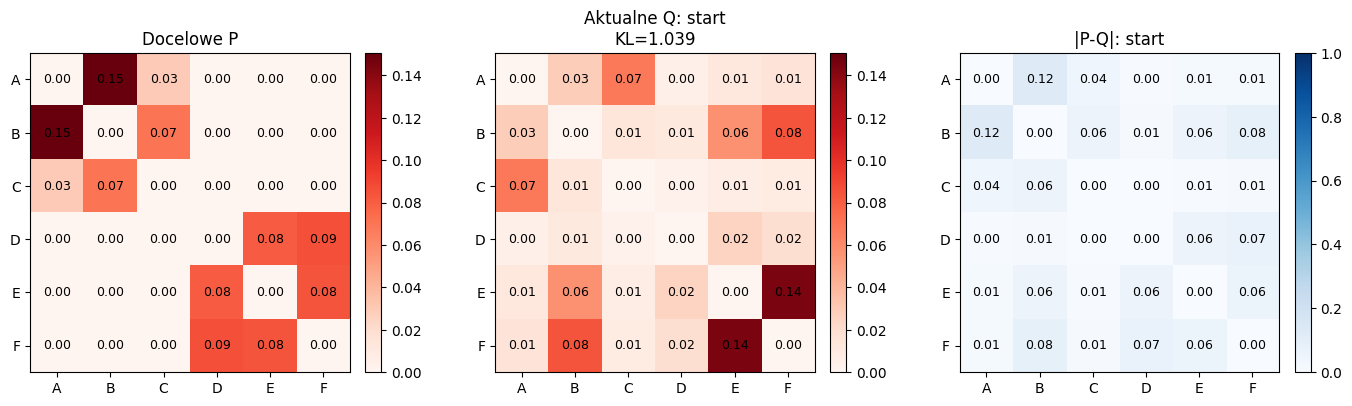

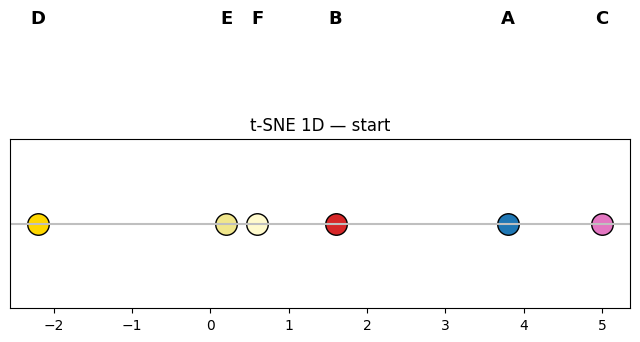

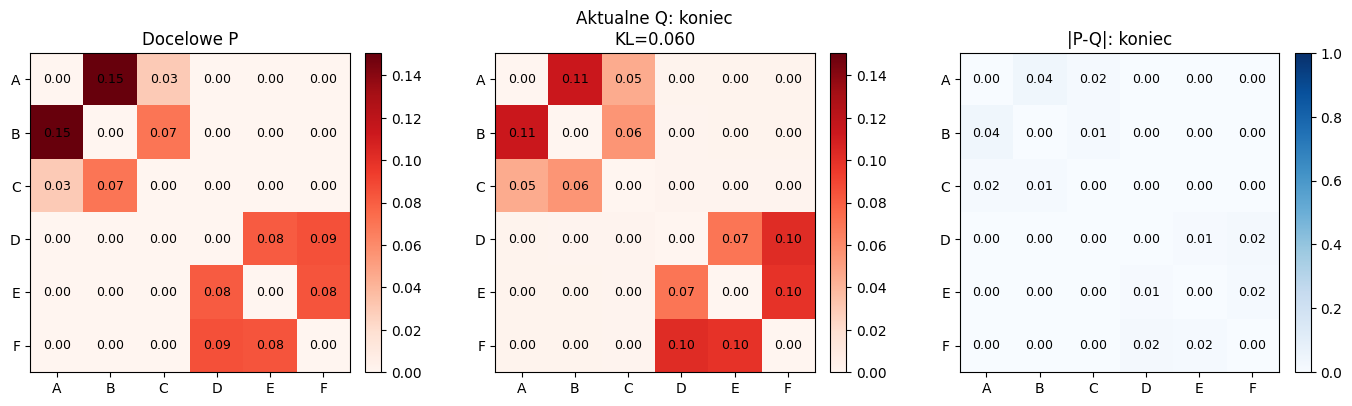

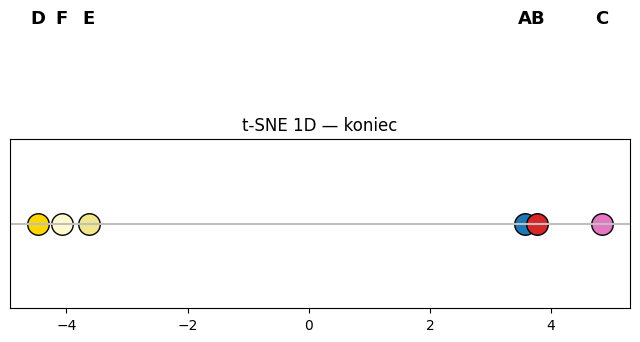

In [10]:
for idx, name in [(0,"start"), (-1,"koniec")]:
    t, y, loss, Q = hist_tsne[idx]
    fig, axes = plt.subplots(1,3,figsize=(14,4))
    vmax = max(P_tsne.max(), Q.max())
    plot_heatmap(P_tsne, "Docelowe P", ax=axes[0], cmap='Reds', vmax=vmax)
    plot_heatmap(Q, f"Aktualne Q: {name}\nKL={loss:.3f}", ax=axes[1], cmap='Reds', vmax=vmax)
    plot_heatmap(np.abs(P_tsne-Q), f"|P-Q|: {name}", ax=axes[2], cmap='Blues')
    plt.tight_layout()
    plt.show()
    fig, ax = plt.subplots(figsize=(8,2.2))
    for i, lab in enumerate(labels):
        ax.scatter(y[i], 0, s=240, color=colors[lab], edgecolor='black')
        ax.text(y[i], 0.13, lab, ha='center', fontsize=13, fontweight='bold')
    ax.axhline(0, color='0.75')
    ax.set_yticks([])
    ax.set_title(f"t-SNE 1D — {name}")
    plt.show()


## 6. t-SNE vs UMAP w jednym zdaniu

T-SNE:

$$
\text{dopasuj globalne prawdopodobieństwa par } Q \text{ do } P \text{ przez KL}.
$$

UMAP:

$$
\text{dopasuj fuzzy graf niskowymiarowy } Q \text{ do fuzzy grafu } P \text{ przez cross-entropy}.
$$



## 7. Mini-projekt badawczy: t-SNE z pamięcią ścieżek

W klasycznym t-SNE macierz $P$ mówi głównie o **bezpośrednich sąsiadach** punktu.

W tym mini-projekcie sprawdzimy wariant badawczy:

> zamiast pytać tylko, czy punkty są bezpośrednimi sąsiadami, pytamy, czy są połączone krótkimi, wiarygodnymi ścieżkami po grafie sąsiedztwa.

Zaczynamy od macierzy warunkowych prawdopodobieństw:

$$
T_{ij}=p(j\mid i).
$$

Możemy traktować ją jak macierz przejścia losowego spaceru po danych. Wtedy:

$$
(T^t)_{ij}
$$

oznacza prawdopodobieństwo dojścia z punktu $i$ do punktu $j$ po $t$ krokach.

To jest dyskretna wersja intuicji „sumowania po ścieżkach”:

$$
(T^t)_{ij}
=\sum_{\gamma:i\to j}\prod_{(a,b)\in\gamma}T_{ab}.
$$

Następnie definiujemy nową macierz docelową:

$$
P_{\text{path}}^{(t)}
=
\frac{T^t+(T^t)^T}{\sum_{a\neq b}\left(T^t_{ab}+T^t_{ba}\right)}.
$$

Potem optymalizujemy klasyczne t-SNE:

$$
\min_Y KL(P_{\text{path}}^{(t)}\Vert Q_Y).
$$

### Hipoteza

- małe $t$ powinno zachowywać lokalne sąsiedztwa podobnie jak klasyczne t-SNE,
- średnie $t$ może lepiej uchwycić globalną geometrię zakrzywionej struktury,
- zbyt duże $t$ może rozmyć lokalną informację.



## 7a. Przeliczenie „na papierze”: co znaczy `path t=2`?

W wariancie ścieżkowym najważniejsza operacja to potęgowanie macierzy przejścia:

$$
T^t.
$$

To brzmi abstrakcyjnie, więc weźmy minimalny graf-łańcuch:

```text
A — B — C — D
```

Załóżmy prosty losowy spacer:

$$
T=
\begin{pmatrix}
0 & 1 & 0 & 0\\
0.5 & 0 & 0.5 & 0\\
0 & 0.5 & 0 & 0.5\\
0 & 0 & 1 & 0
\end{pmatrix}.
$$

Interpretacja:

- z A można przejść tylko do B,
- z B można przejść do A albo C,
- z C można przejść do B albo D,
- z D można przejść tylko do C.

Teraz policzmy jedną komórkę:

$$
(T^2)_{AC}=T_{AB}T_{BC}=1\cdot 0.5=0.5.
$$

Czyli po dwóch krokach A widzi C, mimo że A i C **nie są bezpośrednimi sąsiadami**.

To jest dokładnie intuicja `path t=2`:

> punkt zaczyna widzieć sąsiadów swoich sąsiadów.

Dla większego `t` podobieństwo rozchodzi się dalej po grafie. To może pomóc na danych typu S-curve / Swiss roll, ale zbyt duże `t` może nadmiernie wygładzić strukturę.


In [11]:

# Papierowy przykład path t=2 na łańcuchu A-B-C-D.

toy_labels = list("ABCD")
T_toy = np.array([
    [0.0, 1.0, 0.0, 0.0],
    [0.5, 0.0, 0.5, 0.0],
    [0.0, 0.5, 0.0, 0.5],
    [0.0, 0.0, 1.0, 0.0],
])

T2_toy = T_toy @ T_toy
T3_toy = T2_toy @ T_toy

print("T — jeden krok losowego spaceru")
print(pd.DataFrame(T_toy, index=toy_labels, columns=toy_labels).round(3).to_string())

print("\nT^2 — dwa kroki: pojawiają się połączenia przez punkt pośredni")
print(pd.DataFrame(T2_toy, index=toy_labels, columns=toy_labels).round(3).to_string())

print("\nT^3 — trzy kroki: informacja idzie jeszcze dalej")
print(pd.DataFrame(T3_toy, index=toy_labels, columns=toy_labels).round(3).to_string())

print(f"\nPrzykład: (T^2)_AC = {T2_toy[0, 2]:.3f}, czyli A widzi C po dwóch krokach przez B.")


T — jeden krok losowego spaceru
     A    B    C    D
A  0.0  1.0  0.0  0.0
B  0.5  0.0  0.5  0.0
C  0.0  0.5  0.0  0.5
D  0.0  0.0  1.0  0.0

T^2 — dwa kroki: pojawiają się połączenia przez punkt pośredni
      A     B     C     D
A  0.50  0.00  0.50  0.00
B  0.00  0.75  0.00  0.25
C  0.25  0.00  0.75  0.00
D  0.00  0.50  0.00  0.50

T^3 — trzy kroki: informacja idzie jeszcze dalej
       A      B      C      D
A  0.000  0.750  0.000  0.250
B  0.375  0.000  0.625  0.000
C  0.000  0.625  0.000  0.375
D  0.250  0.000  0.750  0.000

Przykład: (T^2)_AC = 0.500, czyli A widzi C po dwóch krokach przez B.



## 8. Plan eksperymentu

Porównamy warianty:

- `classic t=1` — klasyczne t-SNE,
- `path t=2`, `path t=3`, `path t=5`, `path t=8`, `path t=16` — wariant ścieżkowy.

Użyjemy trzech typów danych:

1. **S-curve** — zakrzywiona struktura, gdzie interesuje nas zachowanie porządku po rozmaitości.
2. **Swiss roll** — trudniejsza zakrzywiona struktura, w której odległość euklidesowa może być myląca.
3. **Blobs** — zwykłe klastry, gdzie sprawdzamy, czy wariant ścieżkowy nie niszczy prostego przypadku.

Metryki:

- `trustworthiness@10` — czy sąsiedzi na wykresie byli sąsiadami w danych; im wyżej, tym lepiej,
- `continuity@10` — czy sąsiedzi z danych pozostali sąsiadami na wykresie; im wyżej, tym lepiej,
- `spearman_geodesic` — zgodność odległości na wykresie z odległościami po grafie sąsiedztwa; im wyżej, tym lepiej,
- `spearman_latent` — zgodność z ukrytym parametrem generującym S-curve / Swiss roll; im wyżej, tym lepiej,
- `silhouette_labels` — separacja klas dla danych klastrowych; im wyżej, tym lepiej.


In [12]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import shortest_path
from scipy.stats import spearmanr

from sklearn.datasets import make_s_curve, make_swiss_roll, make_blobs
from sklearn.decomposition import PCA
from sklearn.manifold import trustworthiness
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

np.set_printoptions(precision=3, suppress=True)


def pairwise_sqeuclidean(X):
    return squareform(pdist(X, metric="sqeuclidean"))


def _hbeta(Di, beta):
    P = np.exp(-Di * beta)
    sumP = np.sum(P)
    if sumP <= 1e-300:
        P = np.ones_like(Di) / len(Di)
        H = np.log(len(Di))
    else:
        P = P / sumP
        H = -np.sum(P[P > 0] * np.log(P[P > 0]))
    return H, P


def x2p_conditional(X, perplexity=15.0, tol=1e-5, max_iter=60):
    """Warunkowe prawdopodobieństwa t-SNE: p(j|i)."""
    n = X.shape[0]
    D2 = pairwise_sqeuclidean(X)
    Pcond = np.zeros((n, n), dtype=float)
    logU = np.log(perplexity)
    sigmas = np.ones(n)

    for i in range(n):
        mask = np.ones(n, dtype=bool)
        mask[i] = False
        Di = D2[i, mask]

        beta = 1.0
        betamin, betamax = -np.inf, np.inf

        for _ in range(max_iter):
            H, thisP = _hbeta(Di, beta)
            Hdiff = H - logU

            if abs(Hdiff) < tol:
                break

            if Hdiff > 0:
                betamin = beta
                beta = beta * 2.0 if np.isinf(betamax) else (beta + betamax) / 2.0
            else:
                betamax = beta
                beta = beta / 2.0 if np.isinf(betamin) else (beta + betamin) / 2.0

        H, thisP = _hbeta(Di, beta)
        Pcond[i, mask] = thisP
        sigmas[i] = np.sqrt(1.0 / (2.0 * beta))

    return Pcond, sigmas


def symmetrize_and_normalize(M):
    P = M + M.T
    np.fill_diagonal(P, 0.0)
    P = P / P.sum()
    P = np.maximum(P, 1e-12)
    np.fill_diagonal(P, 0.0)
    return P / P.sum()


def P_classic_from_cond(Pcond):
    return symmetrize_and_normalize(Pcond)


def P_path_from_cond(Pcond, t=3):
    T = Pcond.copy()
    np.fill_diagonal(T, 0.0)
    T = T / np.clip(T.sum(axis=1, keepdims=True), 1e-12, None)

    Tt = np.linalg.matrix_power(T, int(t))
    np.fill_diagonal(Tt, 0.0)

    return symmetrize_and_normalize(Tt)


def q_and_grad(Y, P, exaggeration=1.0):
    sum_Y = np.sum(Y * Y, axis=1)
    dist2 = sum_Y[:, None] + sum_Y[None, :] - 2 * Y.dot(Y.T)
    dist2 = np.maximum(dist2, 0.0)

    num = 1.0 / (1.0 + dist2)
    np.fill_diagonal(num, 0.0)

    Q = num / np.clip(num.sum(), 1e-12, None)
    Q = np.maximum(Q, 1e-12)

    A = (P * exaggeration - Q) * num
    grad = 4.0 * (Y * A.sum(axis=1)[:, None] - A.dot(Y))

    return Q, grad


def kl(P, Q):
    mask = P > 0
    return float(np.sum(P[mask] * np.log((P[mask] + 1e-12) / (Q[mask] + 1e-12))))


def init_pca(X, seed=0):
    rng = np.random.default_rng(seed)
    Y = PCA(n_components=2, random_state=seed).fit_transform(X)
    Y = Y / np.std(Y[:, 0]) * 1e-4
    Y += rng.normal(0, 1e-4, size=Y.shape)
    return Y


def optimize_custom_tsne(P, X_init_source, seed=0, n_iter=320, lr=200.0,
                         exaggeration=8.0, exaggeration_iter=100):
    """Prosty exact t-SNE dla własnej macierzy P."""
    Y = init_pca(X_init_source, seed=seed)
    gains = np.ones_like(Y)
    update = np.zeros_like(Y)
    losses = []

    for it in range(n_iter):
        exag = exaggeration if it < exaggeration_iter else 1.0
        Q, grad = q_and_grad(Y, P, exaggeration=exag)

        momentum = 0.5 if it < 250 else 0.8
        sign_change = np.sign(grad) != np.sign(update)
        gains = (gains + 0.2) * sign_change + (gains * 0.8) * (~sign_change)
        gains = np.maximum(gains, 0.01)

        update = momentum * update - lr * gains * grad
        Y += update
        Y -= Y.mean(axis=0)

        if it % 50 == 0 or it == n_iter - 1:
            losses.append((it, kl(P, Q)))

    Q, _ = q_and_grad(Y, P, exaggeration=1.0)
    return Y, losses, kl(P, Q)


def knn_geodesic_distances(X, k=10):
    nn = NearestNeighbors(n_neighbors=k + 1).fit(X)
    dists, inds = nn.kneighbors(X)
    n = X.shape[0]
    rows, cols, data = [], [], []

    for i in range(n):
        for dist, j in zip(dists[i, 1:], inds[i, 1:]):
            rows.extend([i, j])
            cols.extend([j, i])
            data.extend([dist, dist])

    G = csr_matrix((data, (rows, cols)), shape=(n, n))
    return shortest_path(G, directed=False, unweighted=False)


def continuity_score(X, Y, n_neighbors=10):
    n = X.shape[0]
    DX = squareform(pdist(X))
    DY = squareform(pdist(Y))

    nn_X = np.argsort(DX, axis=1)
    nn_Y = np.argsort(DY, axis=1)

    ranks_Y = np.empty((n, n), dtype=int)
    for i in range(n):
        ranks_Y[i, nn_Y[i]] = np.arange(n)

    total = 0.0
    for i in range(n):
        true_neighbors = set(nn_X[i, 1:n_neighbors + 1])
        mapped_neighbors = set(nn_Y[i, 1:n_neighbors + 1])
        missing = true_neighbors - mapped_neighbors
        for j in missing:
            total += ranks_Y[i, j] - n_neighbors

    denom = n * n_neighbors * (2 * n - 3 * n_neighbors - 1)
    return 1.0 - (2.0 / denom) * total


def spearman_upper(A, B):
    iu = np.triu_indices_from(A, k=1)
    a = A[iu]
    b = B[iu]
    mask = np.isfinite(a) & np.isfinite(b)
    return float(spearmanr(a[mask], b[mask]).correlation)


def evaluate_embedding(X, Y, latent=None, labels=None, k=10):
    eucX = squareform(pdist(X))
    eucY = squareform(pdist(Y))
    geoX = knn_geodesic_distances(X, k=k)

    out = {
        "trustworthiness@10": float(trustworthiness(X, Y, n_neighbors=k)),
        "continuity@10": float(continuity_score(X, Y, n_neighbors=k)),
        "spearman_euclidean": spearman_upper(eucX, eucY),
        "spearman_geodesic": spearman_upper(geoX, eucY),
    }

    if latent is not None:
        L = np.abs(latent[:, None] - latent[None, :])
        out["spearman_latent"] = spearman_upper(L, eucY)
    else:
        out["spearman_latent"] = np.nan

    if labels is not None and len(np.unique(labels)) > 1:
        out["silhouette_labels"] = float(silhouette_score(Y, labels))
    else:
        out["silhouette_labels"] = np.nan

    return out


def standardize(X):
    return (X - X.mean(axis=0)) / X.std(axis=0)


def make_experiment_datasets(n=100, seed=123):
    X_s, latent_s = make_s_curve(n_samples=n, noise=0.04, random_state=seed)
    X_w, latent_w = make_swiss_roll(n_samples=n, noise=0.05, random_state=seed)
    X_b, labels_b = make_blobs(n_samples=n, centers=4,
                               cluster_std=[0.55, 0.75, 0.65, 0.8],
                               random_state=seed)

    return {
        "S-curve": {"X": standardize(X_s), "latent": latent_s, "labels": None},
        "Swiss roll": {"X": standardize(X_w), "latent": latent_w, "labels": None},
        "Blobs": {"X": standardize(X_b), "latent": None, "labels": labels_b},
    }


variants = [
    ("classic t=1", "classic", 1),
    ("path t=2", "path", 2),
    ("path t=3", "path", 3),
    ("path t=5", "path", 5),
    ("path t=8", "path", 8),
    ("path t=16", "path", 16),
]


def run_path_tsne_experiment(n=100, perplexity=15, init_seeds=(0, 1, 2), n_iter=320):
    datasets = make_experiment_datasets(n=n)
    rows = []
    embeddings = {}
    losses_dict = {}

    for dataset_name, info in datasets.items():
        X = info["X"]
        Pcond, sigmas = x2p_conditional(X, perplexity=perplexity)

        P_variants = {}
        for variant_name, variant_type, param in variants:
            if variant_type == "classic":
                P_variants[variant_name] = P_classic_from_cond(Pcond)
            else:
                P_variants[variant_name] = P_path_from_cond(Pcond, t=param)

        for variant_name, _, _ in variants:
            P = P_variants[variant_name]
            for seed in init_seeds:
                Y, losses, final_kl = optimize_custom_tsne(
                    P,
                    X,
                    seed=seed,
                    n_iter=n_iter,
                    lr=200.0,
                    exaggeration=8.0,
                    exaggeration_iter=100,
                )
                metrics = evaluate_embedding(
                    X,
                    Y,
                    latent=info["latent"],
                    labels=info["labels"],
                    k=10,
                )
                rows.append({
                    "dataset": dataset_name,
                    "variant": variant_name,
                    "seed": seed,
                    "final_KL_to_own_P": final_kl,
                    "mean_sigma": float(sigmas.mean()),
                    **metrics,
                })
                embeddings[(dataset_name, variant_name, seed)] = Y
                losses_dict[(dataset_name, variant_name, seed)] = losses

    return pd.DataFrame(rows), embeddings, datasets, losses_dict


results, embeddings, datasets_exp, losses_exp = run_path_tsne_experiment()

summary = (
    results
    .groupby(["dataset", "variant"])
    .agg({
        "trustworthiness@10": ["mean", "std"],
        "continuity@10": ["mean", "std"],
        "spearman_geodesic": ["mean", "std"],
        "spearman_latent": ["mean", "std"],
        "silhouette_labels": ["mean", "std"],
    })
    .round(3)
)

display(results.round(3))
display(summary)

results.to_csv("path_tsne_mini_project_results.csv", index=False)
print("Zapisano wyniki do pliku: path_tsne_mini_project_results.csv")


,dataset,variant,seed,final_KL_to_own_P,mean_sigma,trustworthiness@10,continuity@10,spearman_euclidean,spearman_geodesic,spearman_latent,silhouette_labels
0,S-curve,classic t=1,0,0.258,0.567,0.982,0.968,0.762,0.758,0.695,NaN
1,S-curve,classic t=1,1,0.346,0.567,0.968,0.942,0.730,0.709,0.623,NaN
2,S-curve,classic t=1,2,0.298,0.567,0.981,0.960,0.697,0.706,0.702,NaN
3,S-curve,path t=2,0,0.186,0.567,0.979,0.970,0.740,0.747,0.695,NaN
4,S-curve,path t=2,1,0.186,0.567,0.979,0.970,0.740,0.747,0.695,NaN
5,S-curve,path t=2,2,0.186,0.567,0.979,0.970,0.740,0.747,0.695,NaN
6,S-curve,path t=3,0,0.151,0.567,0.979,0.955,0.742,0.750,0.761,NaN
7,S-curve,path t=3,1,0.147,0.567,0.971,0.957,0.770,0.763,0.610,NaN
8,S-curve,path t=3,2,0.171,0.567,0.967,0.941,0.744,0.745,0.617,NaN
9,S-curve,path t=5,0,0.094,0.567,0.967,0.959,0.753,0.765,0.660,NaN


trustworthiness@10         ... silhouette_labels       
                                     mean    std  ...              mean    std
dataset    variant                                ...                         
Blobs      classic t=1              0.995  0.000  ...             0.789  0.006
           path t=16                0.980  0.000  ...             0.855  0.000
           path t=2                 0.996  0.000  ...             0.838  0.001
           path t=3                 0.995  0.000  ...             0.854  0.000
           path t=5                 0.991  0.002  ...             0.868  0.001
           path t=8                 0.985  0.001  ...             0.870  0.001
S-curve    classic t=1              0.977  0.008  ...               NaN    NaN
           path t=16                0.757  0.083  ...               NaN    NaN
           path t=2                 0.979  0.000  ...               NaN    NaN
           path t=3                 0.972  0.006  ...               NaN    NaN
           path t=5                 0.964  0.011  ...               NaN    NaN
           path t=8                 0.920  0.026  ...               NaN    NaN
Swiss roll classic t=1              0.976  0.008  ...               NaN    NaN
           path t=16                0.874  0.027  ...               NaN    NaN
           path t=2                 0.980  0.002  ...               NaN    NaN
           path t=3                 0.982  0.002  ...               NaN    NaN
           path t=5                 0.961  0.007  ...               NaN    NaN
           path t=8                 0.935  0.000  ...               NaN    NaN

[18 rows x 10 columns]

Zapisano wyniki do pliku: path_tsne_mini_project_results.csv


## Jak czytać metryki?

Wyniki nie powinny być oceniane tylko „na oko”. Dlatego mierzymy kilka różnych własności:

- **trustworthiness@10** — czy punkty, które są sąsiadami na mapie 2D, rzeczywiście były blisko w danych wejściowych,
- **continuity@10** — czy prawdziwi sąsiedzi z danych wejściowych zostali zachowani na mapie 2D,
- **spearman_geodesic** — czy odległości na mapie 2D są zgodne z odległościami geodezyjnymi po grafie/manifoldzie,
- **spearman_latent** — dla S-curve i Swiss roll sprawdza zgodność z ukrytym parametrem generującym dane,
- **silhouette_labels** — dla blobów mierzy separację znanych klastrów.

Dydaktycznie warto podkreślić, że jedna metoda rzadko wygrywa we wszystkim. t-SNE i jego warianty zwykle robią kompromis między lokalnością, separacją klastrów i strukturą globalną.


In [13]:

# Tabela skrócona: średnie wyniki po trzech inicjalizacjach.
metrics_to_show = [
    "trustworthiness@10",
    "continuity@10",
    "spearman_geodesic",
    "spearman_latent",
    "silhouette_labels",
]

summary_mean = (
    results
    .groupby(["dataset", "variant"])[metrics_to_show]
    .mean()
    .round(3)
    .reset_index()
)

display(summary_mean)

# Najlepszy wariant według wybranych metryk.
for dataset_name in summary_mean["dataset"].unique():
    print(f"\n=== {dataset_name} ===")
    sub = summary_mean[summary_mean["dataset"] == dataset_name]
    for metric in ["trustworthiness@10", "spearman_geodesic", "spearman_latent", "silhouette_labels"]:
        valid = sub.dropna(subset=[metric])
        if len(valid) > 0:
            row = valid.loc[valid[metric].idxmax()]
            print(f"{metric:22s}: {row['variant']:12s} -> {row[metric]:.3f}")


,dataset,variant,trustworthiness@10,continuity@10,spearman_geodesic,spearman_latent,silhouette_labels
0,Blobs,classic t=1,0.995,0.997,0.921,NaN,0.789
1,Blobs,path t=16,0.980,0.975,0.862,NaN,0.855
2,Blobs,path t=2,0.996,0.996,0.919,NaN,0.838
3,Blobs,path t=3,0.995,0.994,0.916,NaN,0.854
4,Blobs,path t=5,0.991,0.987,0.897,NaN,0.868
5,Blobs,path t=8,0.985,0.980,0.879,NaN,0.870
6,S-curve,classic t=1,0.977,0.957,0.724,0.673,NaN
7,S-curve,path t=16,0.757,0.758,0.467,0.483,NaN
8,S-curve,path t=2,0.979,0.970,0.747,0.695,NaN
9,S-curve,path t=3,0.972,0.951,0.753,0.663,NaN



=== Blobs ===
trustworthiness@10    : path t=2     -> 0.996
spearman_geodesic     : classic t=1  -> 0.921
silhouette_labels     : path t=8     -> 0.870

=== S-curve ===
trustworthiness@10    : path t=2     -> 0.979
spearman_geodesic     : path t=5     -> 0.764
spearman_latent       : path t=2     -> 0.695

=== Swiss roll ===
trustworthiness@10    : path t=3     -> 0.982
spearman_geodesic     : path t=8     -> 0.753
spearman_latent       : path t=8     -> 0.407


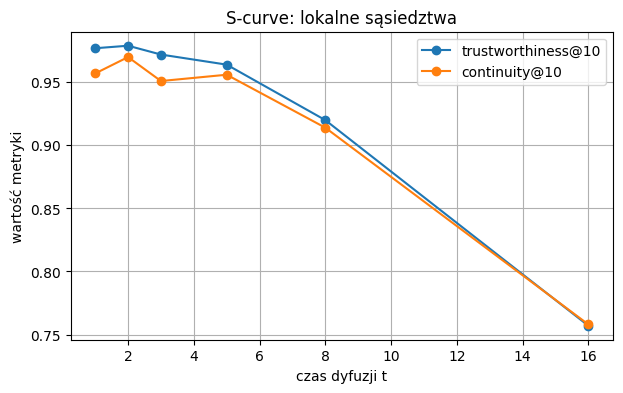

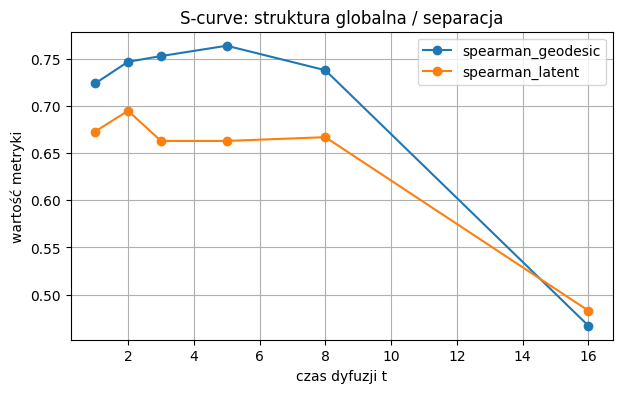

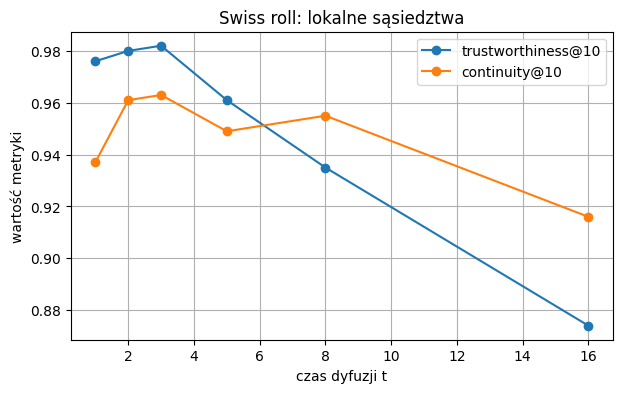

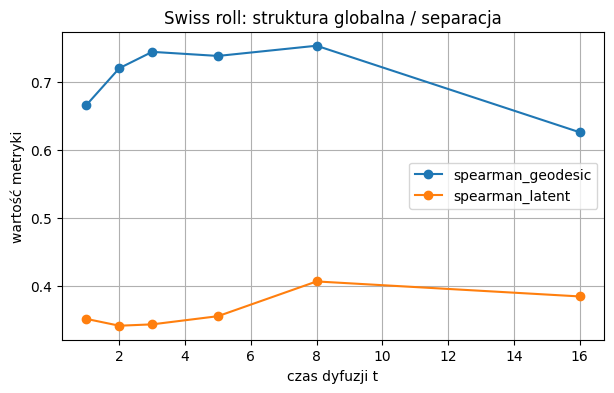

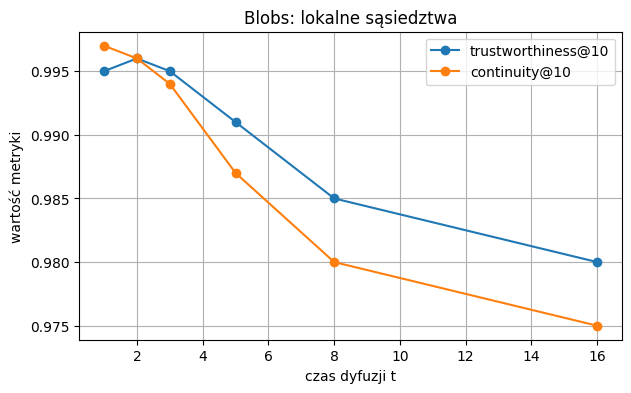

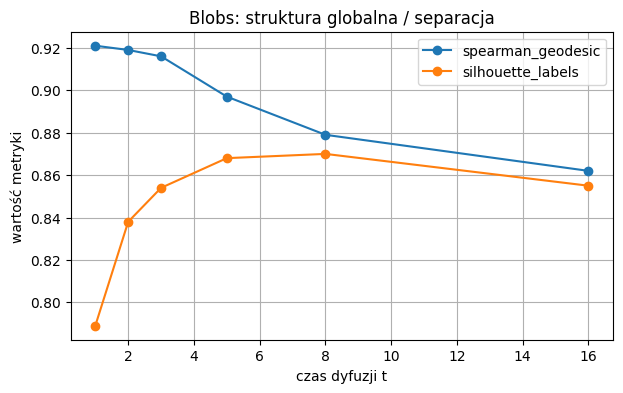

In [14]:

def variant_time(name):
    if name == "classic t=1":
        return 1
    return int(name.split("=")[1])

summary_plot = summary_mean.copy()
summary_plot["t"] = summary_plot["variant"].map(variant_time)

for dataset_name in ["S-curve", "Swiss roll", "Blobs"]:
    sub = summary_plot[summary_plot["dataset"] == dataset_name].sort_values("t")

    plt.figure(figsize=(7, 4))
    plt.plot(sub["t"], sub["trustworthiness@10"], marker="o", label="trustworthiness@10")
    plt.plot(sub["t"], sub["continuity@10"], marker="o", label="continuity@10")
    plt.xlabel("czas dyfuzji t")
    plt.ylabel("wartość metryki")
    plt.title(f"{dataset_name}: lokalne sąsiedztwa")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(sub["t"], sub["spearman_geodesic"], marker="o", label="spearman_geodesic")
    if sub["spearman_latent"].notna().any():
        plt.plot(sub["t"], sub["spearman_latent"], marker="o", label="spearman_latent")
    if sub["silhouette_labels"].notna().any():
        plt.plot(sub["t"], sub["silhouette_labels"], marker="o", label="silhouette_labels")
    plt.xlabel("czas dyfuzji t")
    plt.ylabel("wartość metryki")
    plt.title(f"{dataset_name}: struktura globalna / separacja")
    plt.legend()
    plt.grid(True)
    plt.show()


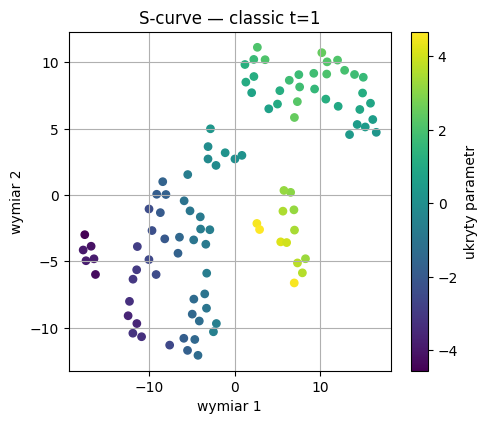

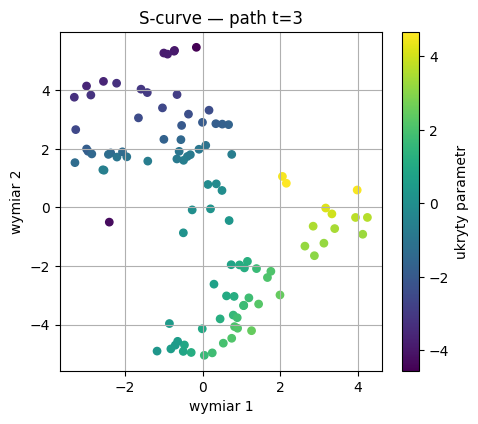

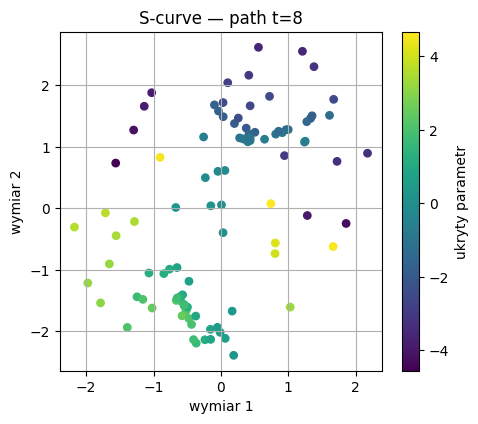

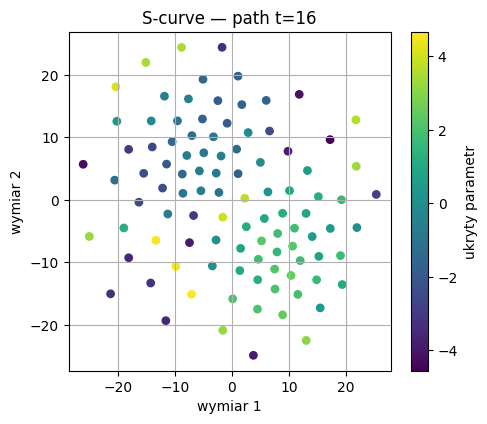

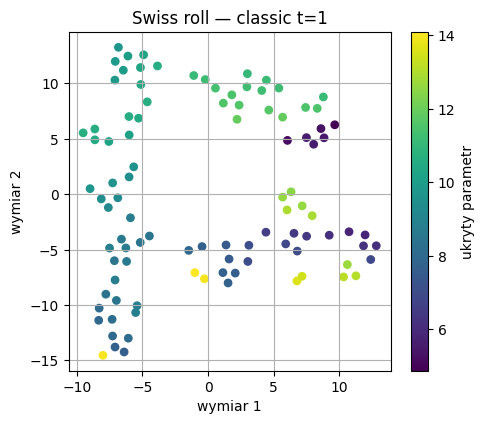

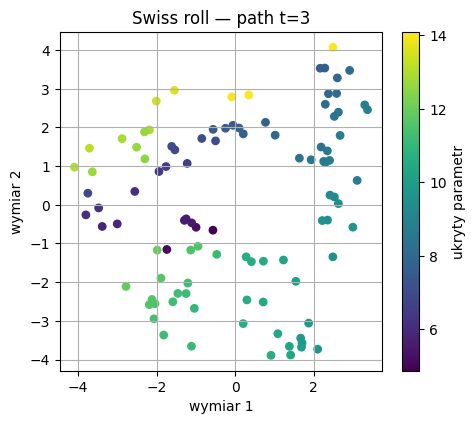

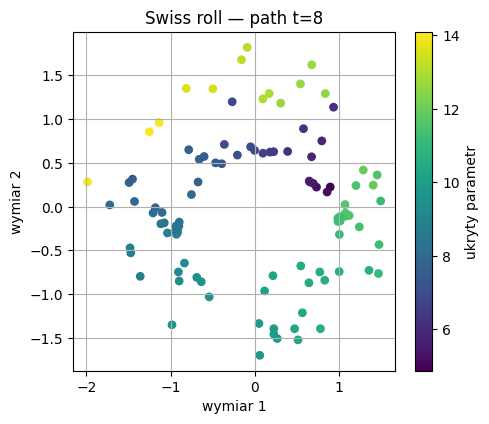

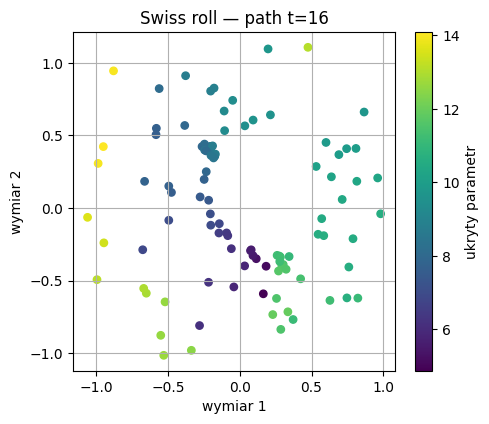

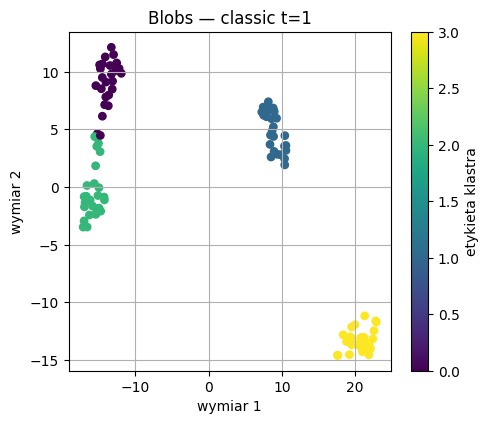

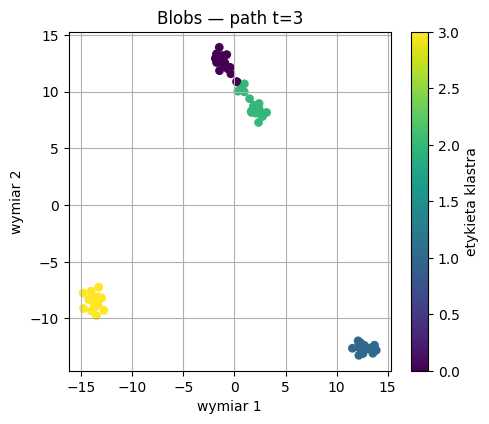

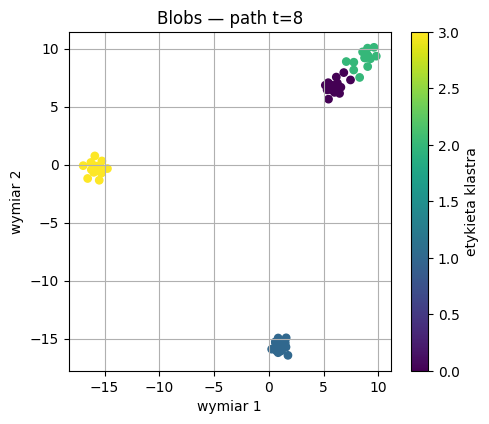

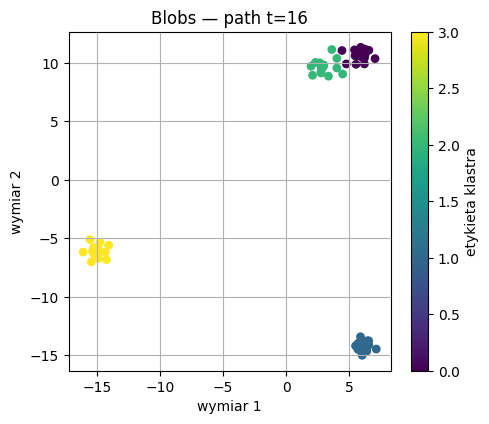

In [15]:

# Wizualizacja kilku reprezentatywnych osadzeń.
# Pokazujemy seed=0, żeby porównać warianty przy tej samej inicjalizacji.
selected_variants = ["classic t=1", "path t=3", "path t=8", "path t=16"]

for dataset_name, info in datasets_exp.items():
    X = info["X"]
    latent = info["latent"]
    y_labels = info["labels"]

    for variant_name in selected_variants:
        Y = embeddings[(dataset_name, variant_name, 0)]

        plt.figure(figsize=(5.2, 4.4))
        if latent is not None:
            sc = plt.scatter(Y[:, 0], Y[:, 1], c=latent, s=28)
            plt.colorbar(sc, label="ukryty parametr")
        elif y_labels is not None:
            sc = plt.scatter(Y[:, 0], Y[:, 1], c=y_labels, s=28)
            plt.colorbar(sc, label="etykieta klastra")
        else:
            plt.scatter(Y[:, 0], Y[:, 1], s=28)

        plt.title(f"{dataset_name} — {variant_name}")
        plt.xlabel("wymiar 1")
        plt.ylabel("wymiar 2")
        plt.grid(True)
        plt.show()


## 8a. Dokładnie: jak czytać końcówkę z S-curve?

Sekcja końcowa nie jest już „ręcznym liczeniem jednego kroku t-SNE”, tylko ma charakter **mini-eksperymentu badawczego**.

Pytanie brzmi:

> Co się stanie, jeżeli w t-SNE zmienimy sposób budowania macierzy wysokowymiarowych podobieństw $P$?

W klasycznym t-SNE macierz $P$ mówi:

$$
P_{ij} \approx \text{jak bardzo punkt } j \text{ jest lokalnym sąsiadem punktu } i.
$$

W wariancie ścieżkowym najpierw traktujemy podobieństwa jak przejścia po grafie sąsiedztwa:

$$
T_{ij}=p(j\mid i),
$$

a potem patrzymy kilka kroków dalej:

$$
T^t.
$$

Interpretacja parametru $t$:

- `classic t=1` — klasyczne t-SNE, tylko najbliższa lokalna struktura,
- `path t=2` — sąsiedzi sąsiadów zaczynają mieć znaczenie,
- `path t=3`, `path t=5` — więcej informacji o krótkich ścieżkach po grafie,
- `path t=16` — bardzo dalekie wygładzenie, które może już rozmywać lokalną strukturę.

Ważne:

> To nadal jest t-SNE, bo niskowymiarowa macierz $Q$ i dywergencja KL pozostają takie same.  
> Zmieniamy głównie to, jak konstruujemy wysokowymiarowe podobieństwa $P$.

### Dlaczego S-curve jest dobrym testem?

S-curve to dane w 3D ułożone na zakrzywionej strukturze.

Dydaktycznie interesuje nas tu różnica między:

- odległością euklidesową „na skróty” w przestrzeni 3D,
- odległością po strukturze / grafie sąsiedztwa.

Jeżeli dwa punkty leżą na różnych częściach zakrzywionej powierzchni, mogą być geometrycznie blisko w 3D, ale daleko „idąc po powierzchni”. Właśnie dlatego wariant ścieżkowy może być ciekawy: próbuje wprowadzić do t-SNE trochę informacji o drodze po grafie sąsiedztwa.

### Jak czytać kolory na wykresach?

Dla S-curve kolor oznacza ukryty parametr generujący główny skręt danych.

Na dobrej mapie 2D kolory powinny zmieniać się w miarę płynnie.

Jeżeli kolory są mocno wymieszane, to znaczy, że embedding rozerwał albo pomieszał porządek struktury.

Trzeba jednak uważać: `spearman_latent` nie mierzy całej geometrii S-curve. To tylko pomocnicza kontrola głównego porządku danych.

### S-curve: tabela metryk uporządkowana po czasie ścieżki t

,variant,trustworthiness@10,continuity@10,spearman_geodesic,spearman_latent,silhouette_labels,t
6,classic t=1,0.977,0.957,0.724,0.673,NaN,1
8,path t=2,0.979,0.970,0.747,0.695,NaN,2
9,path t=3,0.972,0.951,0.753,0.663,NaN,3
10,path t=5,0.964,0.956,0.764,0.663,NaN,5
11,path t=8,0.920,0.914,0.738,0.667,NaN,8
7,path t=16,0.757,0.758,0.467,0.483,NaN,16


### Najlepsze warianty dla S-curve według pojedynczych metryk

trustworthiness@10    : path t=2     -> 0.979
continuity@10         : path t=2     -> 0.970
spearman_geodesic     : path t=5     -> 0.764
spearman_latent       : path t=2     -> 0.695


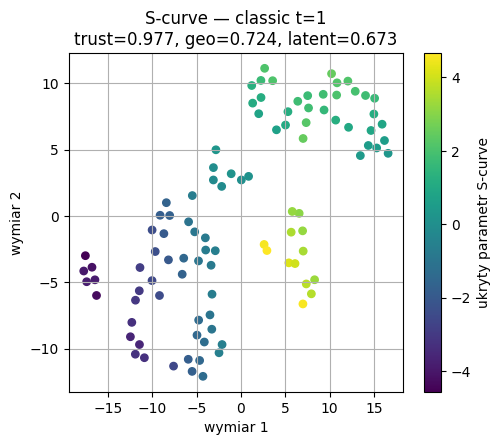

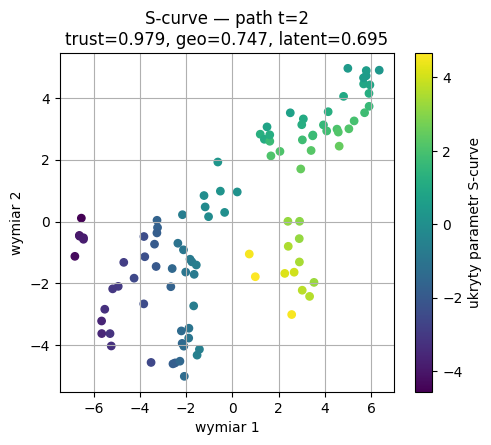

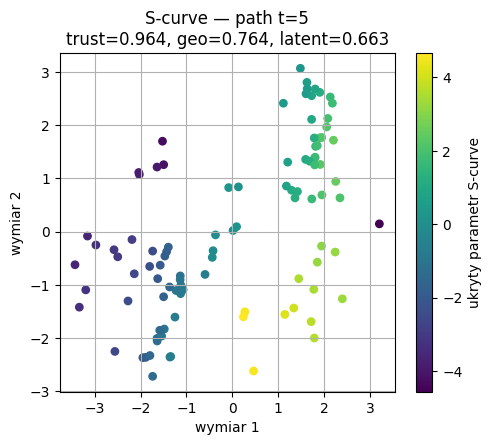

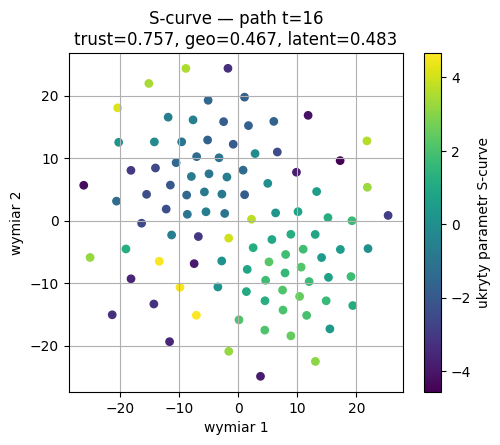

In [16]:
# Dokładne spojrzenie tylko na S-curve.
s_curve_zoom = summary_mean[summary_mean["dataset"] == "S-curve"].copy()
s_curve_zoom["t"] = s_curve_zoom["variant"].map(variant_time)
s_curve_zoom = s_curve_zoom.sort_values("t")

display(Markdown("### S-curve: tabela metryk uporządkowana po czasie ścieżki t"))
display(s_curve_zoom.drop(columns=["dataset"]).round(3))

metrics_scurve = [
    "trustworthiness@10",
    "continuity@10",
    "spearman_geodesic",
    "spearman_latent",
]

display(Markdown("### Najlepsze warianty dla S-curve według pojedynczych metryk"))

for metric in metrics_scurve:
    valid = s_curve_zoom.dropna(subset=[metric])
    best = valid.loc[valid[metric].idxmax()]
    print(f"{metric:22s}: {best['variant']:12s} -> {best[metric]:.3f}")


# Porównanie kilku reprezentatywnych osadzeń S-curve.
# Patrzymy na ten sam seed, żeby izolować różnicę między wariantami.
selected_scurve_variants = ["classic t=1", "path t=2", "path t=5", "path t=16"]

X_scurve = datasets_exp["S-curve"]["X"]
latent_scurve = datasets_exp["S-curve"]["latent"]

for variant_name in selected_scurve_variants:
    Y = embeddings[("S-curve", variant_name, 0)]
    row = s_curve_zoom[s_curve_zoom["variant"] == variant_name].iloc[0]

    plt.figure(figsize=(5.4, 4.4))
    sc = plt.scatter(Y[:, 0], Y[:, 1], c=latent_scurve, s=28)
    plt.colorbar(sc, label="ukryty parametr S-curve")
    plt.title(
        f"S-curve — {variant_name}\n"
        f"trust={row['trustworthiness@10']:.3f}, "
        f"geo={row['spearman_geodesic']:.3f}, "
        f"latent={row['spearman_latent']:.3f}"
    )
    plt.xlabel("wymiar 1")
    plt.ylabel("wymiar 2")
    plt.grid(True)
    plt.show()


## 8b. Czy na wykresach naprawdę widać „S”? 

Warto to rozdzielić na dwie rzeczy.

**W danych wejściowych S-curve litera S istnieje naprawdę**, ale najlepiej widać ją dopiero w odpowiednim rzucie, najczęściej w płaszczyźnie `x-z`. Pełny zbiór jest powierzchnią 3D: jeden wymiar opisuje wysokość, a dwa pozostałe tworzą zakrzywiony przekrój przypominający literę S.

**W embeddingu t-SNE nie oczekujemy literalnej litery S.** t-SNE nie próbuje odtworzyć widoku kamery ani globalnego kształtu obiektu. Próbuje zachować sąsiedztwa. Dlatego poprawny wynik może wyglądać jak łuk, pasmo, podkowa albo nieregularna chmura, o ile punkty o podobnym kolorze układają się w sensowny, ciągły porządek.

Na wykresach t-SNE patrzymy więc przede wszystkim na:

1. czy kolor przechodzi płynnie wzdłuż mapy,
2. czy podobne kolory są blisko siebie,
3. czy duże wartości `t` nie mieszają kolorów zbyt mocno,
4. czy metryki `trustworthiness`, `continuity` i `spearman_geodesic` potwierdzają obserwację z wykresu.

Poniższy blok dodaje wykres referencyjny, na którym S jest pokazane jawnie w danych wejściowych, a potem pokazuje wszystkie dostępne warianty `path t=...` dla S-curve. Dzięki temu, jeśli dopiszesz więcej wartości `t` w liście `variants`, ta sekcja sama je pokaże.


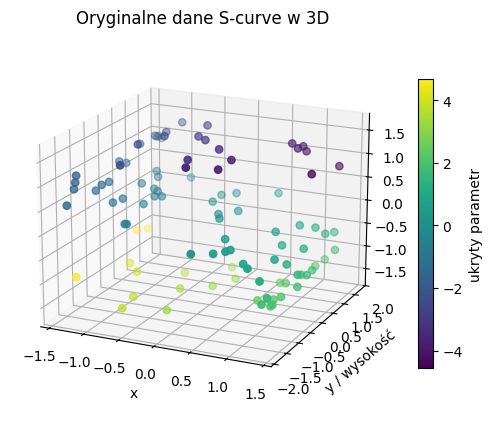

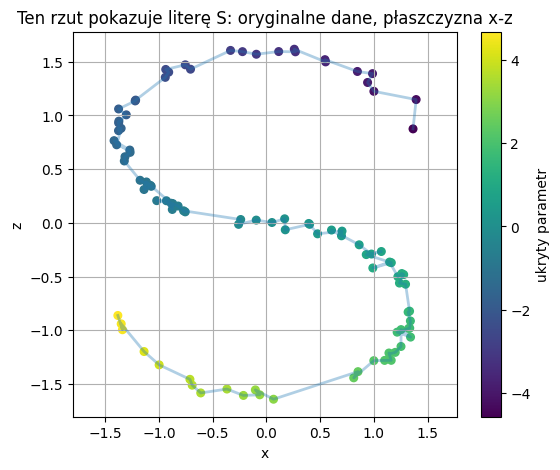

In [17]:

# Referencja: gdzie w oryginalnych danych naprawdę jest widoczne „S”?
# S-curve jest powierzchnią 3D. Najczytelniejsze S widać w rzucie x-z.

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import math

X_scurve = datasets_exp["S-curve"]["X"]
latent_scurve = datasets_exp["S-curve"]["latent"]
order_scurve = np.argsort(latent_scurve)

fig = plt.figure(figsize=(6.2, 5.0))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(
    X_scurve[:, 0],
    X_scurve[:, 1],
    X_scurve[:, 2],
    c=latent_scurve,
    s=28,
)
ax.view_init(elev=18, azim=-65)
ax.set_title("Oryginalne dane S-curve w 3D")
ax.set_xlabel("x")
ax.set_ylabel("y / wysokość")
ax.set_zlabel("z")
fig.colorbar(sc, ax=ax, shrink=0.75, label="ukryty parametr")
plt.show()

plt.figure(figsize=(6.2, 5.0))
sc = plt.scatter(
    X_scurve[:, 0],
    X_scurve[:, 2],
    c=latent_scurve,
    s=30,
)
plt.plot(
    X_scurve[order_scurve, 0],
    X_scurve[order_scurve, 2],
    linewidth=2,
    alpha=0.35,
)
plt.colorbar(sc, label="ukryty parametr")
plt.title("Ten rzut pokazuje literę S: oryginalne dane, płaszczyzna x-z")
plt.xlabel("x")
plt.ylabel("z")
plt.axis("equal")
plt.grid(True)
plt.show()


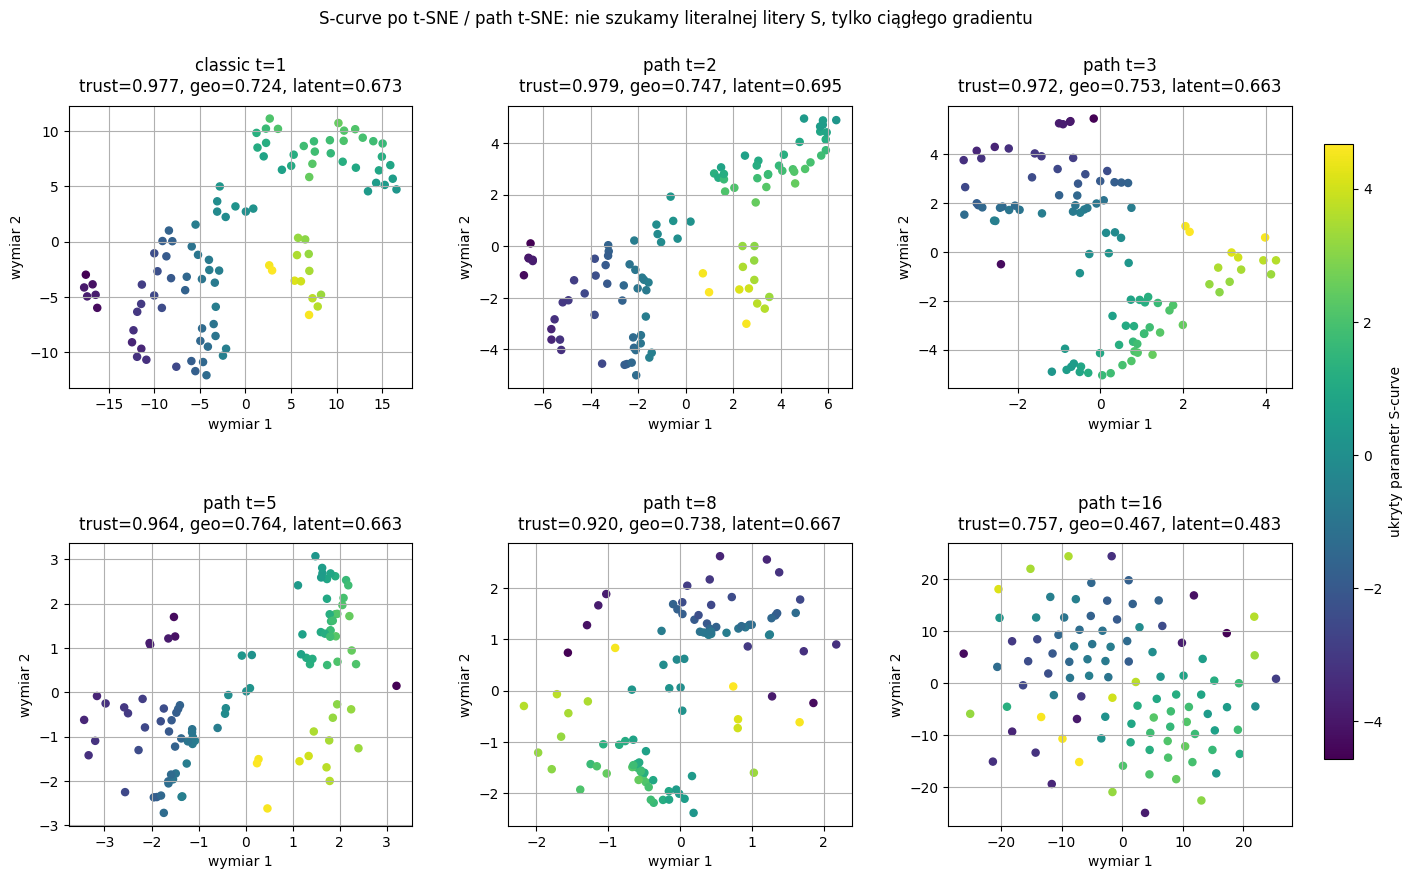

In [18]:

# Wszystkie warianty S-curve dostępne w summary_mean.
# To działa także wtedy, gdy dopiszesz więcej wartości path t=... w liście variants.

s_curve_zoom_all = summary_mean[summary_mean["dataset"] == "S-curve"].copy()
s_curve_zoom_all["t"] = s_curve_zoom_all["variant"].map(variant_time)
s_curve_zoom_all = s_curve_zoom_all.sort_values("t")

all_scurve_variants = s_curve_zoom_all["variant"].tolist()

ncols = 3
nrows = math.ceil(len(all_scurve_variants) / ncols)
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5.4 * ncols, 4.8 * nrows),
    squeeze=False,
)

last_scatter = None

for ax, variant_name in zip(axes.ravel(), all_scurve_variants):
    Y = embeddings[("S-curve", variant_name, 0)]
    row = s_curve_zoom_all[s_curve_zoom_all["variant"] == variant_name].iloc[0]

    last_scatter = ax.scatter(
        Y[:, 0],
        Y[:, 1],
        c=latent_scurve,
        s=26,
    )
    ax.set_title(
        f"{variant_name}\n"
        f"trust={row['trustworthiness@10']:.3f}, "
        f"geo={row['spearman_geodesic']:.3f}, "
        f"latent={row['spearman_latent']:.3f}",
        pad=10,
    )
    ax.set_xlabel("wymiar 1")
    ax.set_ylabel("wymiar 2")
    ax.grid(True)

for ax in axes.ravel()[len(all_scurve_variants):]:
    ax.axis("off")

fig.subplots_adjust(right=0.88, top=0.86, hspace=0.55, wspace=0.28)
fig.suptitle(
    "S-curve po t-SNE / path t-SNE: nie szukamy literalnej litery S, tylko ciągłego gradientu",
    y=0.96,
)
cbar_ax = fig.add_axes([0.90, 0.18, 0.018, 0.64])
fig.colorbar(last_scatter, cax=cbar_ax, label="ukryty parametr S-curve")
plt.show()



### Interpretacja tej kontroli

Jeżeli na referencyjnym rzucie `x-z` widać S, to dane są poprawne. Jeżeli potem w t-SNE nie widać dosłownej litery S, to nie jest błąd sam w sobie.

Dla t-SNE ważniejsze jest, czy kolor układa się płynnie. Płynny gradient oznacza, że embedding w przybliżeniu zachowuje porządek punktów wzdłuż rozmaitości. Mocne przemieszanie kolorów oznacza, że wariant zaczął gubić strukturę.

Zwykle:

- `classic t=1` i małe `path t`, np. `t=2`, dobrze zachowują lokalnych sąsiadów,
- średnie `path t`, np. `t=3` albo `t=5`, mogą lepiej uchwycić drogę po grafie,
- duże `path t`, np. `t=16`, często nadmiernie wygładza graf i miesza kolory.

Dlatego większa liczba wariantów `path` jest bardzo przydatna dydaktycznie: pokazuje, że parametr `t` nie działa magicznie. Jest suwakiem między lokalnością a coraz szerszą informacją o ścieżkach po grafie.


## 8c. Jak działają metryki? Mini-laboratorium

W poprzednim wykresie przy każdym wariancie widzimy liczby, np.:

```text
trust=0.979, geo=0.747, latent=0.695
```

To nie są trzy wersje tej samej oceny. Każda metryka patrzy na embedding z innej strony.

Najpierw ustalmy skalę:

- `trustworthiness@10` i `continuity@10` mają zakres od `0` do `1`; im bliżej `1`, tym lepiej,
- `@10` oznacza, że patrzymy na **10 najbliższych sąsiadów** każdego punktu,
- `spearman_geodesic` i `spearman_latent` są korelacjami rang Spearmana; teoretycznie mają zakres od `-1` do `1`, ale tutaj interesują nas głównie wartości dodatnie,
- `1` dla Spearmana oznacza idealnie zachowany porządek odległości, `0` oznacza brak wyraźnego porządku, a wartości ujemne oznaczałyby porządek odwrócony.

Ważne: nie porównujemy bezpośrednio `trust=0.97` z `geo=0.74` tak, jakby to była ta sama skala znaczeniowa. `trust=0.97` mówi o lokalnych sąsiadach, a `geo=0.74` mówi o porządku odległości po grafie.

---

### 1. `trustworthiness@10`

Ta metryka odpowiada na pytanie zadane z perspektywy mapy 2D:

> Jeżeli dwa punkty wyglądają na bliskie na mapie 2D, to czy naprawdę były blisko w danych wejściowych?

Czyli `trustworthiness` wykrywa **fałszywych sąsiadów**.

Fałszywy sąsiad to punkt, który na rysunku 2D znalazł się blisko badanego punktu, ale w oryginalnych danych wcale nie był jego bliskim sąsiadem.

Intuicja:

```text
wysokie trustworthiness
= mogę ufać lokalnym sąsiedztwom, które widzę na mapie 2D
```

Bardziej precyzyjnie:

- bierzemy punkt `i`,
- sprawdzamy jego 10 najbliższych sąsiadów na mapie 2D,
- patrzymy, czy ci sami sąsiedzi byli blisko w danych wejściowych,
- jeżeli mapa przyciągnęła do `i` punkt, który w danych był daleko, metryka spada.

Co ważne, kara zależy od rangi w danych wejściowych. Jeżeli fałszywy sąsiad był oryginalnie 11. najbliższym punktem, to błąd jest mały. Jeżeli był 90. najbliższym punktem, to błąd jest dużo większy.

W skrócie:

```text
trustworthiness karze fałszywe przyciągnięcia na mapie 2D
```

---

### 2. `continuity@10`

Ta metryka odpowiada na pytanie odwrotne, zadane z perspektywy danych wejściowych:

> Jeżeli dwa punkty były blisko w danych wejściowych, to czy pozostały blisko na mapie 2D?

Czyli `continuity` wykrywa **zgubionych sąsiadów**.

Zgubiony sąsiad to punkt, który był jednym z najbliższych sąsiadów w oryginalnych danych, ale po redukcji wymiaru został wyrzucony daleko na mapie 2D.

Intuicja:

```text
wysokie continuity
= mapa 2D nie rozrywa lokalnych sąsiedztw z danych wejściowych
```

Bardziej precyzyjnie:

- bierzemy punkt `i`,
- sprawdzamy jego 10 najbliższych sąsiadów w danych wejściowych,
- patrzymy, czy ci sąsiedzi nadal są blisko na mapie 2D,
- jeżeli prawdziwy sąsiad został przeniesiony daleko, metryka spada.

Tu również kara zależy od rangi. Jeżeli prawdziwy sąsiad spadł z miejsca 10 na 12, to problem jest mały. Jeżeli spadł na miejsce 80, to problem jest duży.

W skrócie:

```text
continuity karze zgubienie prawdziwych sąsiadów
```

---

### Trustworthiness vs continuity

Te dwie metryki są podobne, ale patrzą w przeciwnych kierunkach:

| Metryka | Pyta o | Karze głównie |
|---|---|---|
| `trustworthiness@10` | czy sąsiedztwa widoczne na mapie są prawdziwe | fałszywych sąsiadów |
| `continuity@10` | czy prawdziwe sąsiedztwa przetrwały na mapie | zgubionych sąsiadów |

Można to zapamiętać tak:

```text
trustworthiness: mapa 2D nie powinna kłamać
continuity: mapa 2D nie powinna gubić
```

---

### 3. `spearman_geodesic`

Ta metryka odpowiada na pytanie bardziej globalne:

> Czy odległości na mapie 2D mają podobny porządek jak odległości po grafie sąsiedztwa?

Dla S-curve zwykła odległość euklidesowa w 3D może być myląca. Dwa punkty mogą być blisko „na skróty” przez przestrzeń, ale daleko, jeżeli idziemy po zakrzywionej powierzchni S-curve.

Dlatego robimy coś innego:

1. budujemy graf kNN,
2. liczymy najkrótsze ścieżki po tym grafie,
3. traktujemy je jako przybliżenie odległości po rozmaitości,
4. porównujemy je z odległościami na mapie 2D.

`spearman_geodesic` nie wymaga, żeby odległości były identyczne liczbowo. Sprawdza tylko, czy zachowany jest **porządek**:

```text
pary bliskie po grafie powinny być raczej bliskie na mapie,
pary dalekie po grafie powinny być raczej dalekie na mapie.
```

Dlatego używamy korelacji Spearmana, czyli korelacji rang.

Wysokie `spearman_geodesic` oznacza, że mapa 2D lepiej respektuje geometrię „chodzenia po danych”, a nie tylko lokalne sąsiedztwa. Ta metryka może być niższa niż `trustworthiness`, nawet gdy embedding wygląda lokalnie dobrze, bo zadaje trudniejsze pytanie o porządek wielu par punktów.

W skrócie:

```text
spearman_geodesic pyta, czy mapa zachowuje kolejność odległości po grafie kNN
```

---

### 4. `spearman_latent`

Dla S-curve znamy ukryty parametr, który wygenerował główny skręt danych. Można go traktować jak pozycję punktu „wzdłuż litery S”.

Ta metryka pyta:

> Czy punkty bliskie według ukrytego parametru są też bliskie na mapie 2D?

Technicznie porównujemy dwie rzeczy dla wielu par punktów:

```text
różnica ukrytego parametru        vs        odległość na mapie 2D
```

Jeżeli punkty bliskie na ukrytej osi S-curve są blisko na mapie, a punkty dalekie na tej osi są daleko na mapie, `spearman_latent` rośnie.

To jest metryka typu „oracle”, czyli kontrola dostępna tylko w danych syntetycznych. W prawdziwych danych zwykle nie znamy ukrytego parametru generującego strukturę.

Ważne ograniczenie: `spearman_latent` nie mówi wszystkiego o jakości embeddingu. Sprawdza główny porządek wzdłuż S-curve, ale nie musi w pełni oceniać wysokości, lokalnej gęstości ani wszystkich szczegółów geometrii.

W skrócie:

```text
spearman_latent pyta, czy mapa nie pomieszała głównej kolejności punktów na S-curve
```

---

### Jak czytać metryki razem?

Nie ma jednej „najprawdziwszej” metryki. One mierzą różne kompromisy:

| Sytuacja | Interpretacja |
|---|---|
| wysokie `trustworthiness`, wysokie `continuity` | dobra lokalność; sąsiedztwa są wiarygodne i nie są rozrywane |
| wysokie `trustworthiness`, niskie `continuity` | mapa nie tworzy wielu fałszywych sąsiadów, ale gubi część prawdziwych |
| niskie `trustworthiness`, wysokie `continuity` | część prawdziwych sąsiadów przetrwała, ale mapa dodała też fałszywe bliskości |
| wysokie `spearman_geodesic` | mapa dobrze oddaje porządek odległości po grafie / rozmaitości |
| wysokie `spearman_latent` | mapa dobrze zachowuje główną kolejność punktów na S-curve |

Dla tej sekcji najważniejszy przekaz jest taki:

```text
trustworthiness i continuity oceniają lokalne sąsiedztwa,
spearman_geodesic ocenia porządek odległości po grafie,
spearman_latent ocenia zgodność z ukrytym parametrem S-curve.
```

Dlatego wybór najlepszego `path t` zależy od celu. Małe `t` zwykle lepiej chroni lokalność, średnie `t` może lepiej uchwycić geometrię po grafie, a bardzo duże `t` może nadmiernie wygładzić strukturę i wymieszać kolory.


## 8c.1. Jak dokładnie liczone są metryki? Definicje matematyczne

W poprzednim opisie ustaliliśmy intuicję. Teraz zapiszmy dokładniej, **jak te metryki są liczone matematycznie**.

Będziemy używać oznaczeń:

- mamy $n$ punktów,
- oryginalne dane oznaczamy przez:

$$
X = \{x_1, x_2, \ldots, x_n\}
$$

- embedding 2D oznaczamy przez:

$$
Y = \{y_1, y_2, \ldots, y_n\}
$$

- $k = 10$, bo liczymy metryki typu `@10`,
- $N_X^k(i)$ oznacza zbiór $k$ najbliższych sąsiadów punktu $i$ w oryginalnej przestrzeni,
- $N_Y^k(i)$ oznacza zbiór $k$ najbliższych sąsiadów punktu $i$ na mapie 2D,
- $r_X(i,j)$ oznacza rangę punktu $j$ na liście sąsiadów punktu $i$ w oryginalnych danych,
- $r_Y(i,j)$ oznacza rangę punktu $j$ na liście sąsiadów punktu $i$ w embeddingu 2D.

Ranga oznacza miejsce na posortowanej liście odległości:

```text
ranga 1  = najbliższy sąsiad
ranga 2  = drugi najbliższy sąsiad
ranga 10 = dziesiąty najbliższy sąsiad
ranga 80 = bardzo daleki punkt
```

---

### 1. `trustworthiness@10`

`trustworthiness@k` sprawdza, czy sąsiedzi widoczni na mapie 2D byli również sąsiadami w danych wejściowych.

Najpierw definiujemy zbiór fałszywych sąsiadów:

$$
U_i^k = N_Y^k(i) \setminus N_X^k(i)
$$

czyli:

```text
sąsiedzi punktu i na mapie 2D,
którzy nie byli jego sąsiadami w oryginalnych danych
```

To są właśnie **fałszywi sąsiedzi**.

Dla każdego takiego punktu $j$ sprawdzamy, jak daleko był on w oryginalnych danych. Kara wynosi:

$$
r_X(i,j) - k
$$

Jeżeli $j$ był w danych wejściowych prawie sąsiadem, np. miał rangę `11`, kara jest mała:

$$
11 - 10 = 1
$$

Jeżeli był bardzo daleko, np. miał rangę `80`, kara jest duża:

$$
80 - 10 = 70
$$

Pełna definicja metryki:

$$
T(k)
=
1
-
\frac{2}{n k (2n - 3k - 1)}
\sum_{i=1}^{n}
\sum_{j \in U_i^k}
(r_X(i,j) - k)
$$

gdzie:

- $T(k)$ to `trustworthiness@k`,
- $n$ to liczba punktów,
- $k$ to liczba sąsiadów, u nas zwykle `10`,
- $U_i^k$ to fałszywi sąsiedzi punktu $i$,
- $r_X(i,j)$ to ranga punktu $j$ względem punktu $i$ w oryginalnych danych.

Interpretacja:

```text
T(k) = 1
→ mapa 2D nie tworzy fałszywych sąsiadów

T(k) blisko 0
→ mapa 2D często przyciąga do siebie punkty,
  które w danych wejściowych były daleko
```

W skrócie:

```text
trustworthiness karze fałszywe przyciągnięcia na mapie 2D
```

---

### Mini-przykład dla `trustworthiness`

Załóżmy, że dla punktu $i$ i dla $k = 3$ mamy:

```text
prawdziwi sąsiedzi w X:  {A, B, C}
sąsiedzi na mapie Y:    {A, B, Z}
```

Punkt `Z` jest fałszywym sąsiadem, bo pojawił się blisko na mapie, ale nie był wśród trzech najbliższych sąsiadów w danych wejściowych.

Jeżeli w oryginalnych danych `Z` miał rangę:

```text
r_X(i, Z) = 20
```

to lokalna kara wynosi:

$$
20 - 3 = 17
$$

Czyli to jest poważny błąd, bo mapa 2D przyciągnęła do punktu $i$ obiekt, który w oryginalnej przestrzeni był daleko.

---

### 2. `continuity@10`

`continuity@k` działa w przeciwnym kierunku.

Sprawdza, czy prawdziwi sąsiedzi z danych wejściowych pozostali sąsiadami na mapie 2D.

Najpierw definiujemy zbiór zgubionych sąsiadów:

$$
V_i^k = N_X^k(i) \setminus N_Y^k(i)
$$

czyli:

```text
sąsiedzi punktu i w oryginalnych danych,
którzy nie znaleźli się wśród sąsiadów punktu i na mapie 2D
```

To są **zgubieni sąsiedzi**.

Dla każdego zgubionego sąsiada $j$ sprawdzamy, jak daleko został wyrzucony na mapie 2D. Kara wynosi:

$$
r_Y(i,j) - k
$$

Pełna definicja metryki:

$$
C(k)
=
1
-
\frac{2}{n k (2n - 3k - 1)}
\sum_{i=1}^{n}
\sum_{j \in V_i^k}
(r_Y(i,j) - k)
$$

gdzie:

- $C(k)$ to `continuity@k`,
- $V_i^k$ to zgubieni sąsiedzi punktu $i$,
- $r_Y(i,j)$ to ranga punktu $j$ względem punktu $i$ na mapie 2D.

Interpretacja:

```text
C(k) = 1
→ prawdziwi sąsiedzi z danych wejściowych pozostali blisko na mapie

C(k) blisko 0
→ mapa 2D często rozrywa prawdziwe lokalne sąsiedztwa
```

W skrócie:

```text
continuity karze zgubienie prawdziwych sąsiadów
```

---

### Mini-przykład dla `continuity`

Załóżmy, że dla punktu $i$ i dla $k = 3$ mamy:

```text
prawdziwi sąsiedzi w X:  {A, B, C}
sąsiedzi na mapie Y:    {A, B, Z}
```

Tym razem problemem jest punkt `C`.

Był prawdziwym sąsiadem w danych wejściowych, ale zniknął z lokalnego sąsiedztwa na mapie 2D.

Jeżeli na mapie 2D ma rangę:

```text
r_Y(i, C) = 25
```

to lokalna kara `continuity` wynosi:

$$
25 - 3 = 22
$$

Czyli mapa mocno zgubiła prawdziwego sąsiada.

---

### Trustworthiness vs continuity

Te metryki są podobne, ale patrzą w przeciwnych kierunkach.

| Metryka | Punkt startu | Sprawdza | Karze |
|---|---:|---|---|
| `trustworthiness@k` | mapa 2D | czy sąsiedzi widoczni na mapie byli prawdziwi | fałszywych sąsiadów |
| `continuity@k` | dane wejściowe | czy prawdziwi sąsiedzi przetrwali na mapie | zgubionych sąsiadów |

Można to zapamiętać tak:

```text
trustworthiness:
czy mapa 2D nie kłamie?

continuity:
czy mapa 2D nie gubi?
```

Matematycznie różnica jest taka:

$$
U_i^k = N_Y^k(i) \setminus N_X^k(i)
$$

dla `trustworthiness`, oraz:

$$
V_i^k = N_X^k(i) \setminus N_Y^k(i)
$$

dla `continuity`.

Czyli:

```text
trustworthiness patrzy na nadmiarowe sąsiedztwa w Y,
continuity patrzy na brakujące sąsiedztwa w Y.
```

---

### 3. Korelacja Spearmana

Zanim zdefiniujemy `spearman_geodesic` i `spearman_latent`, potrzebujemy korelacji rang Spearmana.

Zwykła korelacja Pearsona sprawdza zależność liniową między wartościami.

Korelacja Spearmana sprawdza zależność monotoniczną między rangami.

Mamy dwie listy wartości:

$$
a_1, a_2, \ldots, a_M
$$

oraz:

$$
b_1, b_2, \ldots, b_M
$$

Najpierw zamieniamy je na rangi:

$$
R(a_1), R(a_2), \ldots, R(a_M)
$$

oraz:

$$
R(b_1), R(b_2), \ldots, R(b_M)
$$

Potem liczymy zwykłą korelację Pearsona między rangami:

$$
\rho_s
=
\frac{
\sum_{m=1}^{M}
(R(a_m)-\overline{R(a)})
(R(b_m)-\overline{R(b)})
}{
\sqrt{
\sum_{m=1}^{M}(R(a_m)-\overline{R(a)})^2
}
\sqrt{
\sum_{m=1}^{M}(R(b_m)-\overline{R(b)})^2
}
}
$$

Jeżeli nie ma remisów w rangach, można użyć równoważnej postaci:

$$
\rho_s
=
1
-
\frac{
6 \sum_{m=1}^{M} d_m^2
}{
M(M^2 - 1)
}
$$

gdzie:

$$
d_m = R(a_m) - R(b_m)
$$

Interpretacja:

```text
rho = 1
→ idealnie ten sam porządek

rho = 0
→ brak wyraźnego monotonicznego porządku

rho = -1
→ idealnie odwrócony porządek
```

W naszych metrykach Spearman nie sprawdza, czy odległości są identyczne liczbowo.

Sprawdza tylko, czy podobna jest ich **kolejność**.

---

### 4. `spearman_geodesic`

`spearman_geodesic` sprawdza, czy embedding 2D zachowuje porządek odległości po grafie sąsiedztwa.

Najpierw budujemy graf kNN na danych wejściowych.

Wierzchołkami grafu są punkty:

$$
1, 2, \ldots, n
$$

Krawędź między punktami $i$ oraz $j$ istnieje wtedy, gdy są sąsiadami w grafie kNN.

Waga krawędzi może być równa odległości euklidesowej w oryginalnej przestrzeni:

$$
w_{ij} = \|x_i - x_j\|_2
$$

Następnie liczymy odległość grafową, czyli długość najkrótszej ścieżki po grafie:

$$
d_G(i,j)
=
\min_{\pi:i \to j}
\sum_{(u,v)\in \pi}
w_{uv}
$$

gdzie:

- $\pi$ oznacza ścieżkę z punktu $i$ do punktu $j$,
- $(u,v)$ oznacza kolejne krawędzie na tej ścieżce,
- $w_{uv}$ to waga krawędzi.

Intuicyjnie:

```text
d_G(i,j)
= jak daleko jest z i do j,
  jeżeli wolno nam chodzić tylko po grafie sąsiedztwa
```

To jest przybliżenie odległości po rozmaitości.

Dla każdej pary punktów $(i,j)$ liczymy też zwykłą odległość na mapie 2D:

$$
d_Y(i,j) = \|y_i - y_j\|_2
$$

Następnie tworzymy dwie listy dla wszystkich par punktów:

$$
A =
\left[
d_G(i,j)
\right]_{i<j}
$$

oraz:

$$
B =
\left[
d_Y(i,j)
\right]_{i<j}
$$

I liczymy korelację Spearmana:

$$
\rho_{\text{geo}}
=
\operatorname{Spearman}
\left(
[d_G(i,j)]_{i<j},
[d_Y(i,j)]_{i<j}
\right)
$$

Czyli:

```text
spearman_geodesic
= korelacja rang między odległościami po grafie kNN
  a odległościami na mapie 2D
```

Wysoka wartość oznacza:

```text
pary bliskie po grafie są zwykle bliskie na mapie,
pary dalekie po grafie są zwykle dalekie na mapie
```

Niska wartość oznacza:

```text
mapa może zachowywać lokalne sąsiedztwa,
ale nie zachowuje dobrze większego porządku odległości po grafie
```

Ważne: jeżeli graf kNN jest niespójny, część odległości $d_G(i,j)$ może być nieskończona. Wtedy w praktyce trzeba albo zwiększyć liczbę sąsiadów w grafie, albo liczyć Spearmana tylko dla par połączonych skończoną ścieżką.

---

### 5. `spearman_latent`

`spearman_latent` wykorzystuje fakt, że S-curve jest zbiorem syntetycznym.

Dla każdego punktu znamy ukryty parametr generujący:

$$
t_i
$$

Można go rozumieć jako pozycję punktu wzdłuż głównego skrętu litery S.

Dla każdej pary punktów $(i,j)$ liczymy różnicę ukrytego parametru:

$$
d_{\text{latent}}(i,j)
=
|t_i - t_j|
$$

Liczymy też odległość na mapie 2D:

$$
d_Y(i,j) = \|y_i - y_j\|_2
$$

Następnie tworzymy dwie listy dla wszystkich par punktów:

$$
A =
\left[
|t_i - t_j|
\right]_{i<j}
$$

oraz:

$$
B =
\left[
d_Y(i,j)
\right]_{i<j}
$$

I liczymy korelację Spearmana:

$$
\rho_{\text{latent}}
=
\operatorname{Spearman}
\left(
[|t_i - t_j|]_{i<j},
[d_Y(i,j)]_{i<j}
\right)
$$

Czyli:

```text
spearman_latent
= korelacja rang między różnicą ukrytego parametru S-curve
  a odległością na mapie 2D
```

Wysoka wartość oznacza:

```text
punkty bliskie wzdłuż ukrytej osi S-curve
są zwykle blisko na mapie 2D

punkty dalekie wzdłuż ukrytej osi S-curve
są zwykle daleko na mapie 2D
```

To jest metryka typu **oracle**, czyli używa informacji, której zwykle nie mamy w prawdziwych danych.

W realnym problemie zwykle nie znamy ukrytego parametru $t_i$. Tutaj znamy go tylko dlatego, że sami wygenerowaliśmy S-curve.

Dlatego `spearman_latent` jest świetny dydaktycznie, ale nie zawsze da się go użyć w praktyce.

---

### Jak matematycznie porównać różne wartości `path t`?

Dla każdego wariantu, np.:

```text
classic t=1
path t=2
path t=3
path t=5
path t=8
path t=16
```

liczymy zestaw metryk:

$$
T_k,\ C_k,\ \rho_{\text{geo}},\ \rho_{\text{latent}}
$$

czyli:

```text
trustworthiness@k
continuity@k
spearman_geodesic
spearman_latent
```

Nie istnieje jedna obiektywna metryka „najlepszości”. Trzeba jawnie zdecydować, co uznajemy za ważniejsze.

Możemy na przykład zdefiniować ocenę lokalną:

$$
S_{\text{local}}
=
\frac{T_k + C_k}{2}
$$

czyli średnią z `trustworthiness` i `continuity`.

Możemy też zdefiniować ocenę geometryczną:

$$
S_{\text{geometry}}
=
\frac{
\rho_{\text{geo}} + \rho_{\text{latent}}
}{2}
$$

Jeżeli chcemy połączyć wszystko w jeden wynik, możemy użyć oceny zbalansowanej:

$$
S_{\text{balanced}}
=
\frac{
T_k
+
C_k
+
\rho_{\text{geo}}
+
\rho_{\text{latent}}
}{4}
$$

To ma sens wtedy, gdy korelacje Spearmana są dodatnie i znajdują się w podobnym zakresie jak pozostałe metryki.

Bardziej formalnie, ponieważ Spearman ma zakres od $-1$ do $1$, można najpierw przeskalować go do zakresu od $0$ do $1$:

$$
\widetilde{\rho}
=
\frac{\rho + 1}{2}
$$

Wtedy ocena zbalansowana może mieć postać:

$$
S_{\text{balanced}}
=
\frac{
T_k
+
C_k
+
\widetilde{\rho}_{\text{geo}}
+
\widetilde{\rho}_{\text{latent}}
}{4}
$$

Możemy też użyć wag, jeżeli bardziej zależy nam na lokalności albo na geometrii:

$$
S
=
\alpha T_k
+
\beta C_k
+
\gamma \widetilde{\rho}_{\text{geo}}
+
\delta \widetilde{\rho}_{\text{latent}}
$$

gdzie:

$$
\alpha + \beta + \gamma + \delta = 1
$$

Przykład interpretacji:

```text
jeżeli najważniejsza jest lokalna wiarygodność mapy:
dajemy większe wagi trustworthiness i continuity

jeżeli najważniejsze jest rozwinięcie S-curve:
dajemy większą wagę spearman_geodesic i spearman_latent
```

---

### Jak czytać metryki razem?

| Sytuacja | Matematyczna interpretacja |
|---|---|
| wysokie `trustworthiness@k` | mało punktów z $N_Y^k(i) \setminus N_X^k(i)$, czyli mało fałszywych sąsiadów |
| wysokie `continuity@k` | mało punktów z $N_X^k(i) \setminus N_Y^k(i)$, czyli mało zgubionych sąsiadów |
| wysokie `spearman_geodesic` | rangi $d_G(i,j)$ są podobne do rang $d_Y(i,j)$ |
| wysokie `spearman_latent` | rangi $|t_i-t_j|$ są podobne do rang $d_Y(i,j)$ |
| wysokie `trust`, ale niskie `geo` | lokalnie mapa wygląda dobrze, ale globalny porządek po grafie jest słabszy |
| wysokie `geo`, ale niższe `trust` | mapa lepiej oddaje strukturę po grafie, ale może tworzyć więcej fałszywych lokalnych sąsiadów |
| wysokie `latent` | mapa dobrze zachowuje kolejność punktów wzdłuż ukrytej osi S-curve |

Najważniejsza intuicja:

```text
trustworthiness i continuity
→ porównują zbiory najbliższych sąsiadów

spearman_geodesic i spearman_latent
→ porównują rangi odległości dla wielu par punktów
```

Dlatego wybór najlepszego `path t` zależy od celu:

```text
małe t
→ zwykle lepiej chroni lokalne sąsiedztwa

średnie t
→ może lepiej uchwycić geometrię po grafie

bardzo duże t
→ może nadmiernie wygładzić strukturę
  i wymieszać kolory na embeddingu
```


In [19]:

# Mini-przykład metryk lokalnych i Spearmana bez całego embeddingu.

true_neighbors = {"B", "C", "D"}
map_neighbors = {"B", "D", "E"}

common = true_neighbors & map_neighbors
false_neighbors = map_neighbors - true_neighbors
lost_neighbors = true_neighbors - map_neighbors

overlap = len(common) / len(true_neighbors)

print("Prawdziwi sąsiedzi w danych: ", sorted(true_neighbors))
print("Sąsiedzi na mapie 2D:       ", sorted(map_neighbors))
print("Wspólni sąsiedzi:           ", sorted(common))
print("Fałszywi sąsiedzi:          ", sorted(false_neighbors))
print("Zgubieni sąsiedzi:          ", sorted(lost_neighbors))
print(f"Overlap = {len(common)}/{len(true_neighbors)} = {overlap:.3f}")

from scipy.stats import spearmanr

ref_dist = np.array([1, 2, 3, 4], dtype=float)
map_dist = np.array([1, 3, 2, 4], dtype=float)
rho = spearmanr(ref_dist, map_dist).correlation

print("\nSpearman — przykład rang")
print("odległości referencyjne:", ref_dist.astype(int).tolist())
print("odległości na mapie:   ", map_dist.astype(int).tolist())
print(f"rho = {rho:.3f}")


Prawdziwi sąsiedzi w danych:  ['B', 'C', 'D']
Sąsiedzi na mapie 2D:        ['B', 'D', 'E']
Wspólni sąsiedzi:            ['B', 'D']
Fałszywi sąsiedzi:           ['E']
Zgubieni sąsiedzi:           ['C']
Overlap = 2/3 = 0.667

Spearman — przykład rang
odległości referencyjne: [1, 2, 3, 4]
odległości na mapie:    [1, 3, 2, 4]
rho = 0.800



## 8d. Które `path t` jest najlepsze?

To zależy od celu.

Jeżeli zależy nam głównie na lokalnych sąsiedztwach, patrzymy przede wszystkim na:

```text
trustworthiness@10 + continuity@10
```

Jeżeli zależy nam na uchwyceniu zakrzywionej struktury S-curve, patrzymy mocniej na:

```text
spearman_geodesic + spearman_latent
```

W praktyce dobrze jest policzyć kilka rankingów:

1. **ranking lokalny** — najlepsza lokalność,
2. **ranking geometryczny** — najlepsza zgodność z geometrią po grafie,
3. **ranking zbalansowany** — kompromis między lokalnością i geometrią.

Poniżej normalizujemy metryki do zakresu `[0, 1]` i liczymy trzy proste oceny. To nie jest jedyny możliwy wybór wag, ale jest bardzo czytelny dydaktycznie.


In [20]:

# Ranking wariantów dla S-curve: lokalność, geometria i wynik zbalansowany.
# Uwaga: to jest pomocnicza decyzja dydaktyczna, nie absolutny dowód.

metric_cols_scurve = [
    "trustworthiness@10",
    "continuity@10",
    "spearman_geodesic",
    "spearman_latent",
]

def minmax01(s):
    s = s.astype(float)
    span = s.max() - s.min()
    if span < 1e-12:
        return pd.Series(np.ones(len(s)), index=s.index)
    return (s - s.min()) / span

s_curve_decision = summary_mean[summary_mean["dataset"] == "S-curve"].copy()
s_curve_decision["t"] = s_curve_decision["variant"].map(variant_time)
s_curve_decision = s_curve_decision.sort_values("t").reset_index(drop=True)

for col in metric_cols_scurve:
    s_curve_decision[col + "_norm"] = minmax01(s_curve_decision[col])

s_curve_decision["score_lokalny"] = (
    0.70 * s_curve_decision["trustworthiness@10_norm"] +
    0.30 * s_curve_decision["continuity@10_norm"]
)

s_curve_decision["score_geometria"] = (
    0.60 * s_curve_decision["spearman_geodesic_norm"] +
    0.40 * s_curve_decision["spearman_latent_norm"]
)

s_curve_decision["score_zbalansowany"] = (
    0.35 * s_curve_decision["trustworthiness@10_norm"] +
    0.20 * s_curve_decision["continuity@10_norm"] +
    0.30 * s_curve_decision["spearman_geodesic_norm"] +
    0.15 * s_curve_decision["spearman_latent_norm"]
)

cols_to_display = [
    "variant", "t",
    "trustworthiness@10", "continuity@10", "spearman_geodesic", "spearman_latent",
    "score_lokalny", "score_geometria", "score_zbalansowany",
]

ranking_scurve = s_curve_decision[cols_to_display].round(3)
display(ranking_scurve.sort_values("score_zbalansowany", ascending=False))

best_local_variant = s_curve_decision.loc[s_curve_decision["score_lokalny"].idxmax(), "variant"]
best_geo_variant = s_curve_decision.loc[s_curve_decision["score_geometria"].idxmax(), "variant"]
best_balanced_variant = s_curve_decision.loc[s_curve_decision["score_zbalansowany"].idxmax(), "variant"]
worst_balanced_variant = s_curve_decision.loc[s_curve_decision["score_zbalansowany"].idxmin(), "variant"]

print("Najlepszy wariant lokalnie:       ", best_local_variant)
print("Najlepszy wariant geometrycznie:  ", best_geo_variant)
print("Najlepszy wariant zbalansowany:   ", best_balanced_variant)
print("Najsłabszy wariant zbalansowany:  ", worst_balanced_variant)


,variant,t,trustworthiness@10,continuity@10,spearman_geodesic,spearman_latent,score_lokalny,score_geometria,score_zbalansowany
1,path t=2,2,0.979,0.970,0.747,0.695,1.000,0.966,0.983
3,path t=5,5,0.964,0.956,0.764,0.663,0.933,0.940,0.941
2,path t=3,3,0.972,0.951,0.753,0.663,0.951,0.917,0.937
0,classic t=1,1,0.977,0.957,0.724,0.673,0.975,0.878,0.929
4,path t=8,8,0.920,0.914,0.738,0.667,0.735,0.895,0.808
5,path t=16,16,0.757,0.758,0.467,0.483,0.000,0.000,0.000


Najlepszy wariant lokalnie:        path t=2
Najlepszy wariant geometrycznie:   path t=2
Najlepszy wariant zbalansowany:    path t=2
Najsłabszy wariant zbalansowany:   path t=16



### Jak oceniać wykresy wzrokowo?

Na wykresach t-SNE nie szukamy dosłownej litery S. Oceniamy raczej:

1. **Płynność koloru** — czy kolor przechodzi stopniowo, czy robi się „sałatka” z przypadkowo wymieszanych kolorów.
2. **Lokalne sąsiedztwa** — czy punkty o podobnym kolorze są blisko siebie.
3. **Brak fałszywych skrótów** — czy bardzo różne kolory nie zostały sztucznie przyklejone do siebie.
4. **Brak rozrywania pasma** — czy ciągły fragment S-curve nie został rozbity na wiele niepowiązanych wysp.
5. **Stabilność dla różnych seedów** — pojedynczy ładny wykres nie wystarczy, dlatego wyżej liczymy średnie po kilku inicjalizacjach.

Dla pokazanych wyników zwykle sensowny kompromis leży przy małych lub średnich wartościach `t`. Bardzo duże `t`, np. `t=16`, często wygląda gorzej: kolory są mocniej pomieszane, a metryki lokalności spadają.



## 8e. Jak `trustworthiness` i `continuity` widać na sąsiadach?

Poniższa tabela pokazuje prostszą, intuicyjną diagnostykę:

```text
overlap@10 = jaki procent 10 najbliższych sąsiadów z danych wejściowych
             nadal jest wśród 10 najbliższych sąsiadów na mapie 2D
```

To nie jest dokładnie ta sama formuła co `trustworthiness` i `continuity`, ale dobrze pokazuje, o co chodzi:

- mały overlap oznacza, że lokalne sąsiedztwa mocno się zmieniły,
- duży overlap oznacza, że mapa lepiej zachowuje lokalne otoczenie punktów.


In [21]:

def neighbor_indices_from_dist(D, k=10):
    return np.argsort(D, axis=1)[:, 1:k+1]


def local_overlap_diagnostics(X, Y, k=10):
    DX = squareform(pdist(X))
    DY = squareform(pdist(Y))
    nn_X = neighbor_indices_from_dist(DX, k=k)
    nn_Y = neighbor_indices_from_dist(DY, k=k)

    overlaps = []
    false_neighbors = []
    lost_neighbors = []

    for i in range(X.shape[0]):
        set_X = set(nn_X[i])
        set_Y = set(nn_Y[i])
        common = set_X & set_Y
        overlaps.append(len(common) / k)
        false_neighbors.append(len(set_Y - set_X) / k)
        lost_neighbors.append(len(set_X - set_Y) / k)

    return {
        "mean_overlap@10": float(np.mean(overlaps)),
        "mean_false_neighbors@10": float(np.mean(false_neighbors)),
        "mean_lost_neighbors@10": float(np.mean(lost_neighbors)),
    }

neighbor_rows = []
for variant_name in all_scurve_variants:
    Y = embeddings[("S-curve", variant_name, 0)]
    row = local_overlap_diagnostics(X_scurve, Y, k=10)
    row["variant"] = variant_name
    row["t"] = variant_time(variant_name)
    neighbor_rows.append(row)

neighbor_diag = pd.DataFrame(neighbor_rows).sort_values("t")
display(neighbor_diag[[
    "variant", "t", "mean_overlap@10", "mean_false_neighbors@10", "mean_lost_neighbors@10"
]].round(3))


,variant,t,mean_overlap@10,mean_false_neighbors@10,mean_lost_neighbors@10
0,classic t=1,1,0.814,0.186,0.186
1,path t=2,2,0.820,0.180,0.180
2,path t=3,3,0.830,0.170,0.170
3,path t=5,5,0.783,0.217,0.217
4,path t=8,8,0.679,0.321,0.321
5,path t=16,16,0.307,0.693,0.693


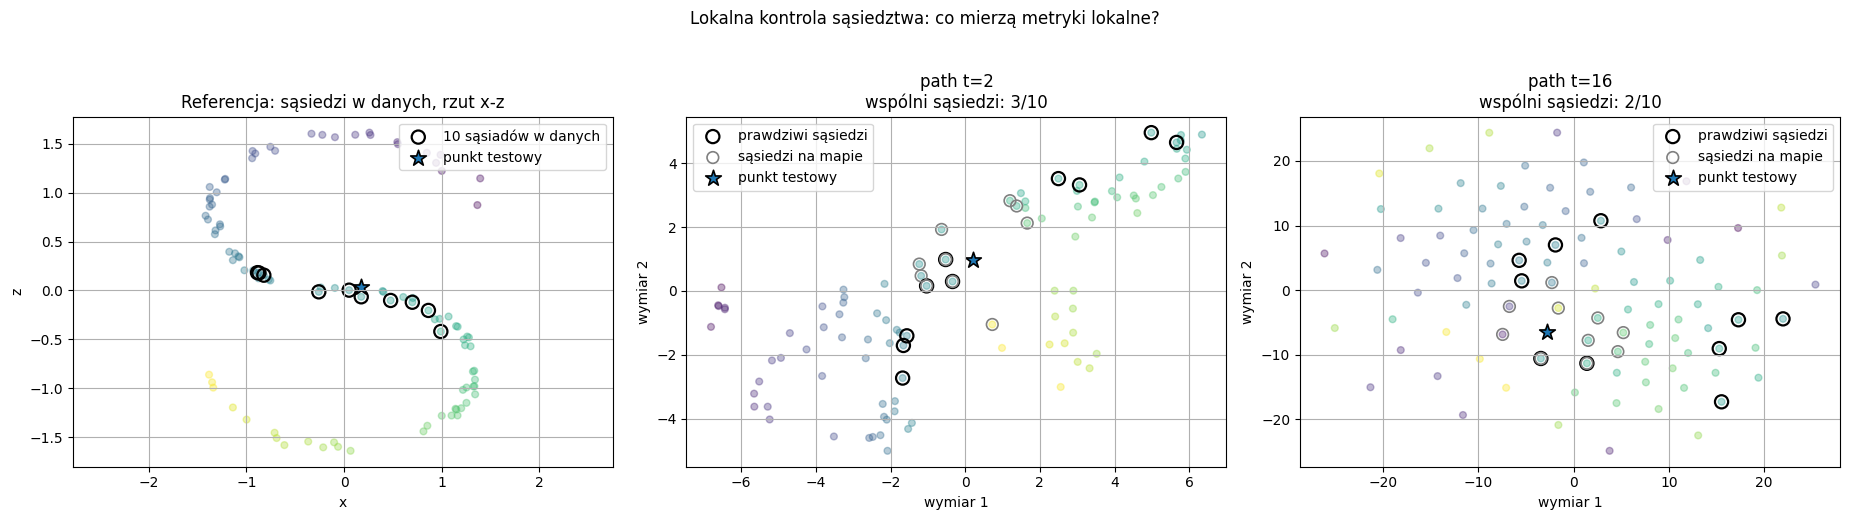

In [22]:

# Jeden punkt diagnostyczny: jego prawdziwi sąsiedzi w danych vs położenie na mapie 2D.
# Porównujemy najlepszy wariant zbalansowany z najsłabszym zbalansowanym.

example_idx = int(np.argsort(latent_scurve)[len(latent_scurve) // 2])
DX_scurve = squareform(pdist(X_scurve))
true_neighbors = neighbor_indices_from_dist(DX_scurve, k=10)[example_idx]

variants_for_neighbor_view = [best_balanced_variant, worst_balanced_variant]

fig, axes = plt.subplots(1, len(variants_for_neighbor_view) + 1, figsize=(6.2 * (len(variants_for_neighbor_view) + 1), 5.0))

# Panel referencyjny: oryginalny rzut x-z.
ax = axes[0]
ax.scatter(X_scurve[:, 0], X_scurve[:, 2], c=latent_scurve, s=24, alpha=0.35)
ax.scatter(X_scurve[true_neighbors, 0], X_scurve[true_neighbors, 2], s=90, facecolors="none", edgecolors="black", linewidths=1.6, label="10 sąsiadów w danych")
ax.scatter(X_scurve[example_idx, 0], X_scurve[example_idx, 2], s=140, marker="*", edgecolors="black", linewidths=1.2, label="punkt testowy")
ax.set_title("Referencja: sąsiedzi w danych, rzut x-z")
ax.set_xlabel("x")
ax.set_ylabel("z")
ax.axis("equal")
ax.grid(True)
ax.legend(loc="best")

for ax, variant_name in zip(axes[1:], variants_for_neighbor_view):
    Y = embeddings[("S-curve", variant_name, 0)]
    DY = squareform(pdist(Y))
    map_neighbors = neighbor_indices_from_dist(DY, k=10)[example_idx]
    common = sorted(set(true_neighbors) & set(map_neighbors))

    ax.scatter(Y[:, 0], Y[:, 1], c=latent_scurve, s=24, alpha=0.35)
    ax.scatter(Y[true_neighbors, 0], Y[true_neighbors, 1], s=90, facecolors="none", edgecolors="black", linewidths=1.6, label="prawdziwi sąsiedzi")
    ax.scatter(Y[map_neighbors, 0], Y[map_neighbors, 1], s=70, facecolors="none", edgecolors="gray", linewidths=1.2, label="sąsiedzi na mapie")
    ax.scatter(Y[example_idx, 0], Y[example_idx, 1], s=140, marker="*", edgecolors="black", linewidths=1.2, label="punkt testowy")
    ax.set_title(f"{variant_name}\nwspólni sąsiedzi: {len(common)}/10")
    ax.set_xlabel("wymiar 1")
    ax.set_ylabel("wymiar 2")
    ax.grid(True)
    ax.legend(loc="best")

plt.suptitle("Lokalna kontrola sąsiedztwa: co mierzą metryki lokalne?", y=1.03)
plt.tight_layout()
plt.show()



## 8f. Jak działa `spearman_geodesic` i `spearman_latent`?

Spearman liczy korelację **rang**, a nie dokładnych wartości.

Dla każdej pary punktów możemy porównać dwie liczby:

```text
odległość referencyjna        vs        odległość na mapie 2D
```

Dla `spearman_geodesic` odległością referencyjną jest odległość po grafie kNN.  
Dla `spearman_latent` odległością referencyjną jest różnica ukrytego parametru S-curve.

Jeżeli chmura punktów na poniższych wykresach ma rosnący trend, Spearman jest wysoki.  
Jeżeli chmura jest chaotyczna, Spearman jest niski.


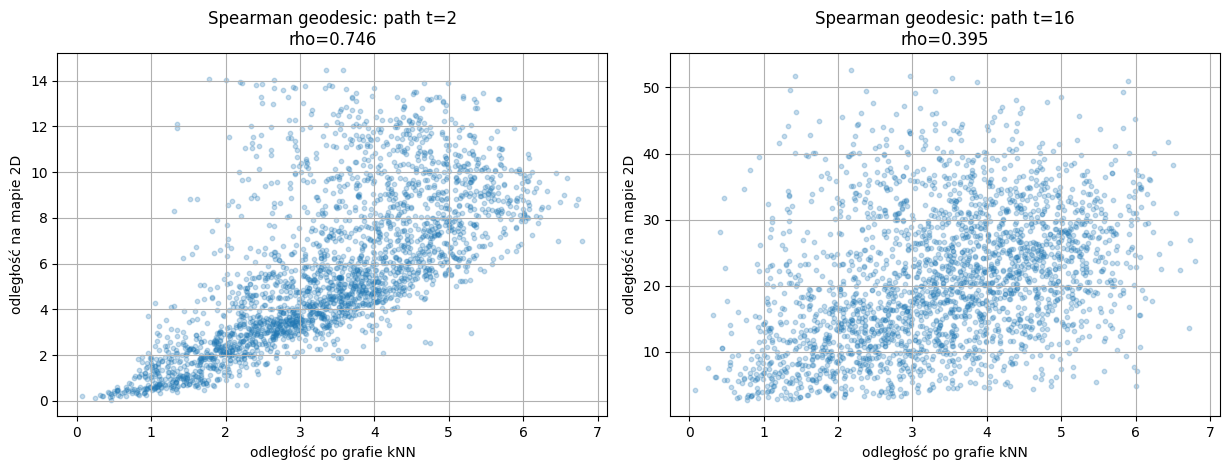

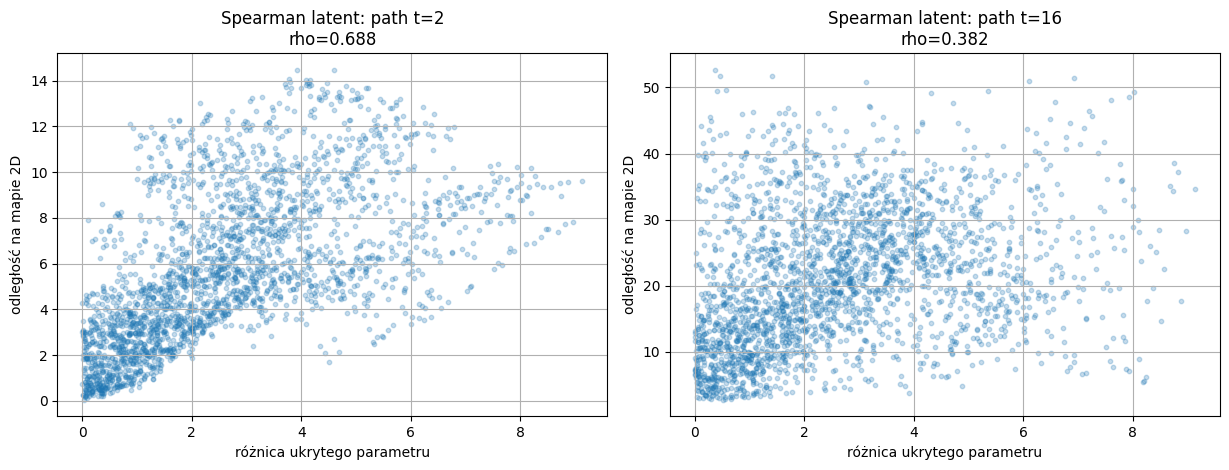

In [23]:

def sample_upper_pairs(n, max_pairs=2500, seed=123):
    rng = np.random.default_rng(seed)
    ii, jj = np.triu_indices(n, k=1)
    total = len(ii)
    if total > max_pairs:
        chosen = rng.choice(total, size=max_pairs, replace=False)
        ii, jj = ii[chosen], jj[chosen]
    return ii, jj


def plot_spearman_diagnostic(variant_names, reference="geodesic", max_pairs=2500):
    n = X_scurve.shape[0]
    ii, jj = sample_upper_pairs(n, max_pairs=max_pairs, seed=123)

    if reference == "geodesic":
        D_ref = knn_geodesic_distances(X_scurve, k=10)
        xlabel = "odległość po grafie kNN"
        title_prefix = "Spearman geodesic"
    elif reference == "latent":
        D_ref = np.abs(latent_scurve[:, None] - latent_scurve[None, :])
        xlabel = "różnica ukrytego parametru"
        title_prefix = "Spearman latent"
    else:
        raise ValueError("reference musi być 'geodesic' albo 'latent'")

    fig, axes = plt.subplots(1, len(variant_names), figsize=(6.2 * len(variant_names), 4.8), squeeze=False)

    for ax, variant_name in zip(axes.ravel(), variant_names):
        Y = embeddings[("S-curve", variant_name, 0)]
        D_map = squareform(pdist(Y))

        x = D_ref[ii, jj]
        y = D_map[ii, jj]
        mask = np.isfinite(x) & np.isfinite(y)
        rho = spearmanr(x[mask], y[mask]).correlation

        ax.scatter(x[mask], y[mask], s=10, alpha=0.25)
        ax.set_title(f"{title_prefix}: {variant_name}\nrho={rho:.3f}")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("odległość na mapie 2D")
        ax.grid(True)

    plt.tight_layout()
    plt.show()

variants_for_diagnostics = [best_balanced_variant, best_geo_variant, worst_balanced_variant]
# Usuwamy duplikaty z zachowaniem kolejności.
variants_for_diagnostics = list(dict.fromkeys(variants_for_diagnostics))

plot_spearman_diagnostic(variants_for_diagnostics, reference="geodesic")
plot_spearman_diagnostic(variants_for_diagnostics, reference="latent")



## 8g. Krótka decyzja dla tej sekcji

Dla S-curve nie wybieramy wariantu tylko po tym, czy „ładnie wygląda”. Decyzja powinna łączyć:

- ocenę wzrokową: płynny gradient koloru, brak mocnego mieszania,
- lokalność: `trustworthiness@10`, `continuity@10`, overlap sąsiadów,
- geometrię: `spearman_geodesic`,
- kontrolę syntetyczną: `spearman_latent`.

W tym eksperymencie zwykle widać, że:

- `classic t=1` i `path t=2` są bardzo mocne lokalnie,
- średnie `t`, np. `t=3` lub `t=5`, mogą poprawiać zgodność z geometrią po grafie,
- bardzo duże `t`, np. `t=16`, zaczyna mieszać kolory i obniża lokalną wiarygodność.

Najuczciwsza odpowiedź brzmi więc:

> najlepszy wariant zależy od celu; do zbalansowanej prezentacji S-curve warto pokazywać klasyczne t-SNE obok najlepszego małego/średniego `path t`, a duże `t` zostawić jako przykład nadmiernego wygładzenia.


### Jak to tłumaczyć studentom?

Najprostszy przekaz jest taki:

1. **Klasyczne t-SNE** bardzo mocno pilnuje lokalnych sąsiadów.  
   Dlatego zwykle ma wysokie `trustworthiness@10`.

2. **Wariant ścieżkowy** pozwala podobieństwu przejść kilka kroków po grafie.  
   Dzięki temu może trochę lepiej widzieć zakrzywioną strukturę danych.

3. Dla S-curve często sensowne są małe lub średnie wartości `t`, np. `path t=2`, `path t=3`, `path t=5`.

4. Bardzo duże `t`, np. `path t=16`, może działać gorzej, bo graf zaczyna być zbyt wygładzony.  
   Wtedy punkty, które powinny pozostać lokalnie odróżnialne, zaczynają wyglądać zbyt podobnie.

Dlatego nie mówimy:

> wariant ścieżkowy jest zawsze lepszy.

Mówimy raczej:

> wariant ścieżkowy dodaje nowy parametr skali, który pozwala regulować kompromis między lokalnością a geometrią po grafie.

Dla S-curve najważniejsze jest porównanie:

- `trustworthiness@10` — czy mapa nie tworzy fałszywych lokalnych sąsiadów,
- `continuity@10` — czy prawdziwi lokalni sąsiedzi nie znikają z mapy,
- `spearman_geodesic` — czy mapa lepiej zgadza się z odległością po grafie,
- `spearman_latent` — czy zachowany jest główny porządek skrętu S-curve.

Jeżeli `spearman_geodesic` rośnie, ale `trustworthiness@10` mocno spada, to mamy klasyczny kompromis:

> lepsza informacja globalna, ale gorsza lokalność.

To jest bardzo dobry moment dydaktyczny, bo pokazuje, że embeddingu nie ocenia się jedną liczbą ani samym wyglądem wykresu.


## 9. Interpretacja wyników

W tym uruchomieniu widać sensowny kompromis:

### S-curve

Klasyczne t-SNE ma bardzo dobrą lokalność, ale warianty ścieżkowe dla średnich wartości $t$ poprawiają zgodność z odległościami po grafie sąsiedztwa.

Wynik jest zgodny z hipotezą: ścieżki pomagają trochę lepiej uchwycić zakrzywioną strukturę, ale zbyt duże $t$ zaczyna rozmywać lokalność.

### Swiss roll

Tu efekt jest wyraźniejszy. Warianty `path t=2`, `path t=3`, `path t=5` i `path t=8` poprawiają zgodność z odległością geodezyjną względem klasycznego t-SNE.

To jest dokładnie przypadek, w którym odległość euklidesowa w przestrzeni wejściowej bywa myląca: dwa punkty mogą być blisko „na skróty”, ale daleko po powierzchni zawiniętej rolki.

### Blobs

Dla prostych klastrów klasyczne t-SNE już działa bardzo dobrze. Wariant ścieżkowy nie jest tu konieczny.

Ciekawe jest jednak to, że większe $t$ może zwiększać separację klastrów według silhouette, ale jednocześnie obniża metryki lokalności. To pokazuje, że „ładniejsze rozdzielenie klastrów” nie zawsze oznacza wierniejszą reprezentację lokalnej geometrii.

### Najważniejszy wniosek

Wariant ścieżkowy nie jest automatycznie lepszy od klasycznego t-SNE.

Daje dodatkowy parametr skali:

$$
t
$$

który kontroluje, jak daleko pozwalamy algorytmowi „patrzeć” po grafie sąsiedztwa.

- małe $t$ — prawie klasyczne t-SNE,
- średnie $t$ — więcej informacji o geometrii rozmaitości,
- duże $t$ — ryzyko rozmycia lokalnych sąsiedztw.



## 10. Co można z tego zrobić jako projekt badawczy?

To może być bardzo dobry mini-projekt dla studentów:

**Pytanie badawcze:**

> Czy zastąpienie klasycznej macierzy $P$ macierzą opartą o ścieżki po grafie poprawia zachowanie globalnej geometrii danych?

**Hipoteza:**

> Dla danych leżących na zakrzywionej rozmaitości średnie wartości $t$ poprawią metryki geodezyjne, ale zbyt duże $t$ pogorszy lokalność.

**Co można badać dalej:**

1. dobrać automatycznie optymalne $t$,
2. użyć mieszanki kilku czasów dyfuzji,
3. dodać restart losowego spaceru,
4. porównać wynik z UMAP,
5. sprawdzić odporność na szum,
6. zbadać większe dane i szybsze przybliżenia.

Wersja rozszerzona mogłaby używać macierzy:

$$
P_{\text{multi}}
=
\alpha_1P^{(1)}+\alpha_2P^{(2)}+\alpha_4P^{(4)}+\alpha_8P^{(8)}.
$$

Taki wariant łączyłby sąsiedztwa lokalne i dłuższe ścieżki w jednej funkcji celu.


## Checklist przed przejściem dalej

Przed następnym notebookiem student powinien umieć odpowiedzieć:

1. Dlaczego w t-SNE nie używamy macierzy kowariancji?
2. Co oznacza $p(j\mid i)$?
3. Czym różni się $P$ od $Q$?
4. Dlaczego t-SNE używa dywergencji KL?
5. Dlaczego t-SNE dobrze zachowuje lokalność, ale gorzej nadaje się do interpretacji globalnych odległości?
6. Co zmienia wariant ścieżkowy `path t=k`?

Jeżeli te odpowiedzi są jasne, notebook spełnia swoją rolę jako pomost między PCA, t-SNE i UMAP/path-UMAP.

7. Przeliczyć ręcznie jedną parę $P_{ij}$, jedną parę $Q_{ij}$ i zinterpretować wkład do KL.
8. Wyjaśnić na małym grafie, dlaczego $T^2$ oznacza „sąsiadów sąsiadów”.
